<a href="https://colab.research.google.com/github/KunakaDK/TReND-CaMinA/blob/main/TrendCamina_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
    <h1> Project 6:  Decoding with the Allen Brain Observatory </h1>

In this project, we are going to explore decoding of stimulus informatin using data from the Allen Brain Observatory.  We will look at how we can decode stimulus information and ask questions about what doing so can tell us about neural responses.  This project picks up where the decoding tutorial left off.
    
For the examples we provide we will look at the 'Drifting Gratings' stimulus.  You might consider a similar project that looks at another stimulus.


</div>

In [ ]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

### Standard imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# we're going to need lists of colors below
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.values())

Scikit-learn is the standard machine learning package in python.  You can import it with the command below.

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import confusion_matrix

### Allen Brain Observatory set up

This instantiates the tools in the Allen SDK that allow us to access the Brain Observatory data.

In [ ]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [ ]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"

    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "allen-brain-observatory","visual-coding-2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

The following cells retrieve the same data session that was used in the tutorial.

In [ ]:
# cell_id = 541513979 # Not in use
# exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_id], stimuli=['drifting_gratings'])
# session_id = exps[0]['id']

In [ ]:
def get_experiment_session_list():
    """Returns a list of session_ids for all sessions that use the drifting grating stimulus
    from areas VISp and VISl and from cre lines Cux2 and Slc17"""
    return [x['id'] for x in boc.get_ophys_experiments(stimuli=['drifting_gratings'],
                                                       targeted_structures=['VISp'],
                                                       cre_lines=['Rorb-IRES2-Cre'] )]

In [ ]:
get_experiment_session_list() #The highest number of neurones in Session_ID one 510214538

[510214538,
 644026238,
 587344053,
 590168385,
 531348161,
 501729039,
 512270518,
 527048992]

In [ ]:
session_id = 510214538

The following cell returns the data for session 'session_id' and puts it into the 'data_set' object.

In [ ]:
data_set = boc.get_ophys_experiment_data(session_id)

In [ ]:
timestamps, dff = data_set.get_dff_traces()
stim_table = data_set.get_stimulus_table('drifting_gratings')

In [ ]:
num_neurons = dff.shape[0]
num_trials = stim_table.shape[0]

In [ ]:
stim_ori = stim_table.orientation.dropna().unique()
stim_tf = stim_table.temporal_frequency.dropna().unique()
stim_ori, stim_tf

(array([270., 225.,  45., 315., 180., 135.,  90.,   0.], dtype=float32),
 array([15.,  8.,  2.,  4.,  1.], dtype=float32))

In [ ]:
stim_ori_grid, stim_tf_grid = np.meshgrid(stim_ori, stim_tf)
stim_tf_ori = np.column_stack((stim_ori_grid.ravel(), stim_tf_grid.ravel()))

In [ ]:
for ori in stim_ori:
  for tf in stim_tf:
    print(stim_table[(stim_table.orientation == ori) & (stim_table.temporal_frequency == tf)])

     temporal_frequency  orientation  blank_sweep   start     end
0                  15.0        270.0          0.0     746     805
165                15.0        270.0          0.0   15645   15705
170                15.0        270.0          0.0   16097   16157
228                15.0        270.0          0.0   51133   51192
236                15.0        270.0          0.0   51855   51915
267                15.0        270.0          0.0   54654   54714
281                15.0        270.0          0.0   55918   55978
299                15.0        270.0          0.0   57543   57603
317                15.0        270.0          0.0   59170   59230
324                15.0        270.0          0.0   59802   59862
363                15.0        270.0          0.0   63324   63383
511                15.0        270.0          0.0  104688  104748
563                15.0        270.0          0.0  109383  109443
564                15.0        270.0          0.0  109473  109533
616       

In [ ]:
#stim_table.groupby(['orientation','temporal_frequency']).count()

stim_table

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [ ]:
num_trials

628

In [ ]:
num_neurons

284

In [ ]:
def get_dff_traces_and_stim_table(cell_specimen_id, stimulus):
    """Retrieves DFF traces and stimulus table for a given neuron and stimulus.

    Args:
        cell_specimen_id (int): The ID of the cell specimen.
        stimulus (str): The name of the stimulus (e.g., 'drifting_gratings').

    Returns:
        tuple: A tuple containing:
            - timestamps (numpy.ndarray): Timestamps for the DFF trace.
            - dff_trace (numpy.ndarray): The DF/F trace for the specified cell.
            - stim_table (pandas.DataFrame): The stimulus table for the specified stimulus.
    """
    #identify the session for a given cell id and stimulus
    exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_specimen_id], stimuli=[stimulus])

    #get the session_id for that session
    session_id = exps[0]['id']

    #access the data for that session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for the cell
    timestamps, dff = data_set.get_dff_traces(cell_specimen_ids=[cell_specimen_id])
    dff_trace = dff[0,:]

    #get the stimulus table for the stimulus
    stim_table = data_set.get_stimulus_table(stimulus)

    #return everything
    return (timestamps, dff_trace, stim_table)

In [ ]:
# Fixed: the function needs a real cell_specimen_id and a stimulus name.
# Grab an actual cell from the session we're already working with (510214538),
# so this pulls the same session rather than a different random one.
cell_id = data_set.get_cell_specimen_ids()[0]
timestamps, dff_trace, stim_table_single = get_dff_traces_and_stim_table(cell_id, 'drifting_gratings')
print(f"cell_id={cell_id}, dff_trace shape={dff_trace.shape}")

cell_id=517526083, dff_trace shape=(115479,)


In [ ]:
dff.shape , timestamps.shape

((284, 115479), (115479,))

Text(0, 0.5, 'DFF')

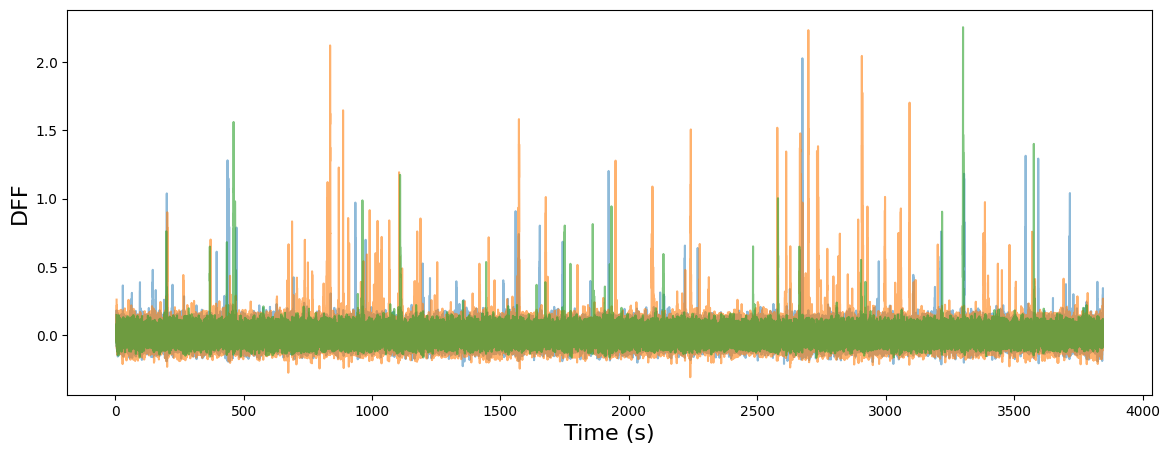

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(timestamps, dff[1,:],alpha = 0.5)
plt.plot(timestamps, dff[200,:],alpha = 0.6)
plt.plot(timestamps, dff[100,:],alpha = 0.6)

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("DFF", fontsize=16)

In [ ]:
def compute_stim_and_response(dff, stim_table):

    num_neurons = dff.shape[0]
    num_trials = stim_table.shape[0]

    activity = np.zeros([num_trials, num_neurons])
    stim = []

    for i, row in stim_table.iterrows():
      activity[i] = dff[:,int(row.start):int(row.end)].mean(axis=1)
      if np.isfinite(row.orientation) and np.isfinite(row.temporal_frequency):
        stim.append(f"{row.orientation}_{row.temporal_frequency}")
      else:
        stim.append('blank') # If either orientation or temporal_frequency is NaN, it's a blank trial

    stim = np.array(stim)

    return activity, stim

In [ ]:
response, stim = compute_stim_and_response(dff, stim_table)
response.shape

(628, 284)

In [ ]:
stim.shape

(628,)

# Classifying cells for stimulus

Let's compute all the tuning curves quickly.

(This is essentially the same computation we did last time don't slightly differently, and for all the neurons simultaneously.)

In [ ]:
def compute_dg_tuning_curve(response, stim, stim_table):
    num_neurons = response.shape[1]

    # Get unique combined stimulus labels from the 'stim' array
    # Filter out 'blank' and sort them for consistent order
    combined_stim_labels_raw = np.unique(stim)
    combined_stim_labels = [label for label in combined_stim_labels_raw if label != 'blank']
    combined_stim_labels.sort()

    num_combined_stim = len(combined_stim_labels)
    tuning_curves = np.zeros([num_neurons, num_combined_stim])

    for i, combined_label in enumerate(combined_stim_labels):
      mask = stim==combined_label
      if np.any(mask): # Only compute mean if there are trials for this stimulus
        tuning_curves[:,i] = response[mask,:].mean(axis=0)
      else:
        # If no trials for this stimulus, fill with NaN to indicate no data
        tuning_curves[:,i] = np.nan

    return tuning_curves, combined_stim_labels # Also return labels for further use

In [ ]:
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)

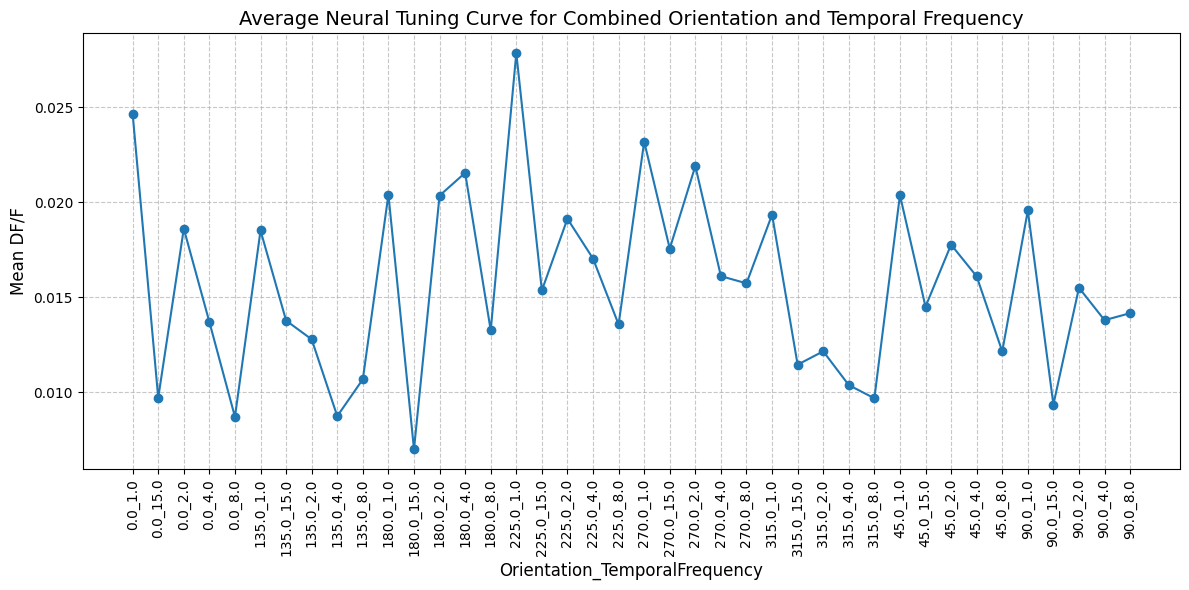

In [ ]:
tuning_curves_data, combined_stim_labels = tuning_curves

# Calculate the mean response across all neurons for each stimulus combination
mean_tuning_curve = np.nanmean(tuning_curves_data, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(combined_stim_labels, mean_tuning_curve, 'o-')

plt.xlabel("Orientation_TemporalFrequency", fontsize=12)
plt.ylabel("Mean DF/F", fontsize=12)
plt.title("Average Neural Tuning Curve for Combined Orientation and Temporal Frequency", fontsize=14)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
orientations = np.sort(stim_table.orientation.unique())
orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']

Let's look at decoding with all of the neurons again.

In [ ]:
test_index = int(0.75*num_trials)

response_test = response[test_index:]
response_train = response[:test_index]

stim_test = stim[test_index:]
stim_train = stim[:test_index]

(response_test.shape, stim_test.shape), (response_train.shape, stim_train.shape)

(((157, 284), (157,)), ((471, 284), (471,)))

In [ ]:
all_neuron_classifier = LDA()
all_neuron_classifier.fit(response_train, stim_train)

LinearDiscriminantAnalysis()

In [ ]:
stim_train_hat = all_neuron_classifier.predict(response_train)
stim_test_hat = all_neuron_classifier.predict(response_test)

In [ ]:
print("Percentage correct on training set:  ", np.mean(stim_train_hat == stim_train))

print("Percentage correct on testing set:  ", np.mean(stim_test_hat == stim_test))

Percentage correct on training set:   1.0
Percentage correct on testing set:   0.34394904458598724


How does this classifier perform on the training set!  What about the test set?  (If there is a difference, why?)

Where is the classifier making mistakes?

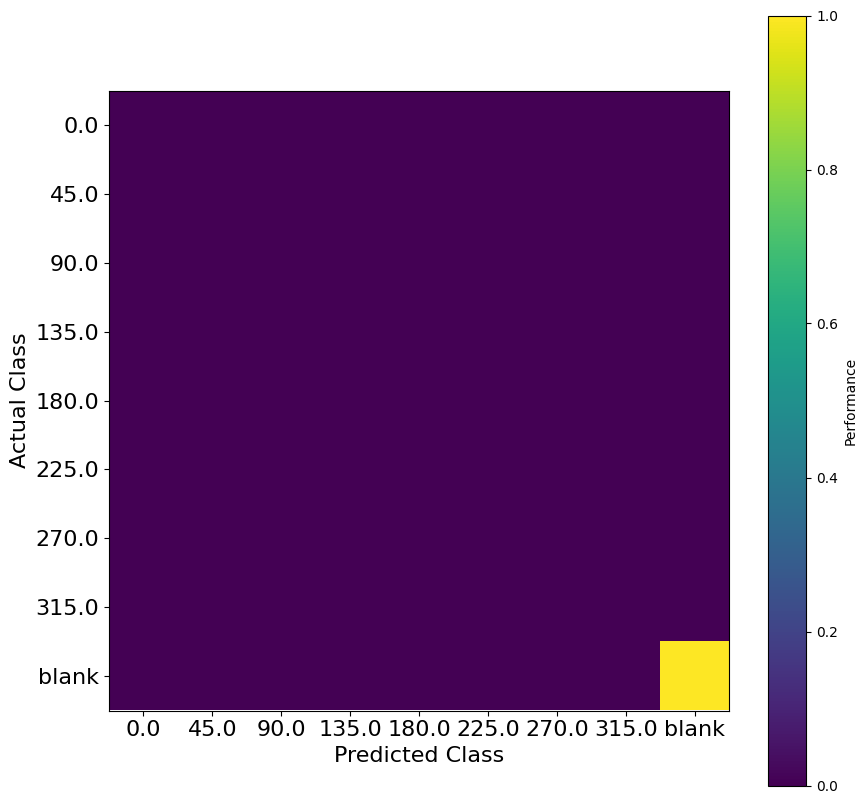

In [ ]:
C = confusion_matrix(stim_test, stim_test_hat, normalize='true', labels=orientation_labels)
# Note that normalization is needed when all classes are not of the same size
# The default is to plot based on counts

num_classes = len(orientation_labels)

plt.figure(figsize=(10, 10))
ax = plt.subplot(111)
cax = ax.imshow(C,interpolation='none', vmin=0, vmax=C.max())

ax.set_xlabel('Predicted Class', fontsize=16)
ax.set_ylabel('Actual Class', fontsize=16)

ax.set_xticks(range(num_classes))
ax.set_xticklabels(orientation_labels, fontsize=16)

ax.set_yticks(range(num_classes))
ax.set_yticklabels(orientation_labels, fontsize=16)

cbar = plt.colorbar(cax)
cbar.set_label('Performance')

We see adding neurons provides more information to the classifier.  How many neurons do we need for good accuracy?

Let's examine how the decoding performance depends upon the number of neurons by randomly selecting a group of neurons of each size.  What does this tell us?  How can we improve this measurement?

In [ ]:
performance = np.zeros(num_neurons-2)

test_index = int(0.75*num_trials)
stim_test_n = stim[test_index:]
stim_train_n = stim[:test_index]

for n in range(2, num_neurons):
  neuron_indices = np.random.permutation(np.arange(num_neurons))[:n] # choose n random neurons

  response_test_n = response[test_index:, neuron_indices]
  response_train_n = response[:test_index, neuron_indices]

  n_classifier = LDA()
  n_classifier.fit(response_train_n, stim_train_n)

  stim_test_hat_n = n_classifier.predict(response_test_n)

  performance[n-2] = np.mean(stim_test_hat_n == stim_test_n)

Text(0.5, 0, 'number of neurons')

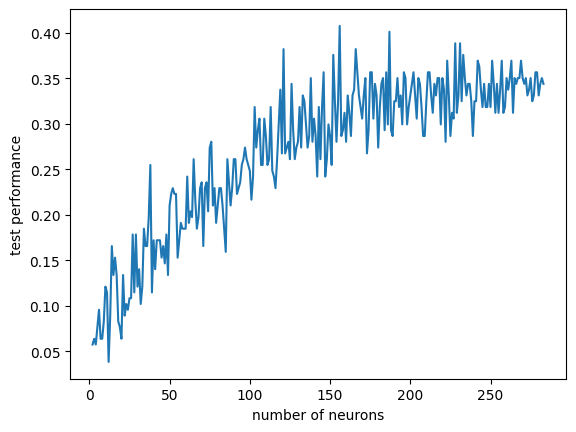

In [ ]:
plt.plot(np.arange(2,num_neurons), performance)
plt.ylabel('test performance')
plt.xlabel('number of neurons')

Questions for future directions:

1. How did we define the test and train sets for these classifications?  What effects do you think this might have on our result?  Can you think of a better way?  What results do you get?

2. Which neurons are the most informative, i.e. which neurons carry the most weight for the classification?  What are the tuning properties of these neurons (i.e. how does the tuning curve relate to the weights in the classifier)?  If you used a different classifier, how would that change your answer to this question?

3.  How would you select the "best" neurons for decoding?  In machine learning this problem is called feature selection.  What methods might be best for this problem?  What are the results?  Are the neurons that are best for decoding the same as the neurons that have robust tuning curves?

4.  If you grab another experiment (code below), what do you need to keep in mind if you want to compare decoding performance across the two experiments?  what can you conclude (if anything) by comparing these two experiments?

Important functions that we used and defined above:

```
# this returns the data for a session identified by session_id
data_set = boc.get_ophys_experiment_data(session_id)

# this returns the timestamps and delta-F/F traces for the set of neurons imaged in that session
timestamps, dff = data_set.get_dff_traces()

# this returns the stimulus information
stim_table = data_set.get_stimulus_table('drifting_gratings')

# compute_stim_and_response is defined IN THIS NOTEBOOK.
response, stim = compute_stim_and_response(dff, stim_table)
# response is [num_trials, num_neurons] and stim is [num_trials]
# response[t,i] gives the response of neuron i to trial t
# stim[t] tells you the stimulus condition of the drifting grating for trial t

# compute_dg_tuning_curve is defined IN THIS NOTEBOOK
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)
# tuning_curves is [num_neurons, num_orientations-1]

```


In [ ]:
session_id=510214538
data_set = boc.get_ophys_experiment_data(session_id)


In [ ]:
data_set.get_stimulus_table('drifting_gratings')

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [ ]:

timestamps, dff = data_set.get_dff_traces()
stim_table = data_set.get_stimulus_table('drifting_gratings')

In [ ]:
stim_table

,temporal_frequency,orientation,blank_sweep,start,end
0,15.0,270.0,0.0,746,805
1,15.0,225.0,0.0,836,896
2,8.0,45.0,0.0,926,986
3,15.0,315.0,0.0,1017,1076
4,2.0,180.0,0.0,1107,1167
...,...,...,...,...,...
623,15.0,0.0,0.0,114802,114862
624,2.0,90.0,0.0,114893,114952
625,4.0,135.0,0.0,114983,115043
626,2.0,180.0,0.0,115073,115133


In [ ]:
num_neurons = dff.shape[0]
num_trials = stim_table.shape[0]

In [ ]:
def compute_stim_and_response(dff, stim_table):

    num_neurons = dff.shape[0]
    num_trials = stim_table.shape[0]

    activity = np.zeros([num_trials, num_neurons])
    stim = []   # why are we using a list?

    for i, row in stim_table.iterrows():
      activity[i] = dff[:,int(row.start):int(row.end)].mean(axis=1) #  compute the mean for *each* neuron
      if np.isfinite(row.orientation):
        stim.append(str(row.orientation))
      else:
        stim.append('blank')

    stim = np.array(stim)

    return activity, stim

In [ ]:
response, stim = compute_stim_and_response(dff, stim_table)

In [ ]:
dff.shape

(284, 115479)

In [ ]:
def get_dff_traces_and_stim_table(cell_specimen_id, stimulus):
    """Retrieves DFF traces and stimulus table for a given neuron and stimulus.

    Args:
        cell_specimen_id (int): The ID of the cell specimen.
        stimulus (str): The name of the stimulus (e.g., 'drifting_gratings').

    Returns:
        tuple: A tuple containing:
            - timestamps (numpy.ndarray): Timestamps for the DFF trace.
            - dff_trace (numpy.ndarray): The DF/F trace for the specified cell.
            - stim_table (pandas.DataFrame): The stimulus table for the specified stimulus.
    """
    #identify the session for a given cell id and stimulus
    exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_specimen_id], stimuli=[stimulus])

    #get the session_id for that session
    session_id = exps[0]['id']

    #access the data for that session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for the cell
    timestamps, dff = data_set.get_dff_traces(cell_specimen_ids=[cell_specimen_id])
    dff_trace = dff[0,:]

    #get the stimulus table for the stimulus
    stim_table = data_set.get_stimulus_table(stimulus)

    #return everything
    return (timestamps, dff_trace, stim_table)

Text(0, 0.5, 'DFF')

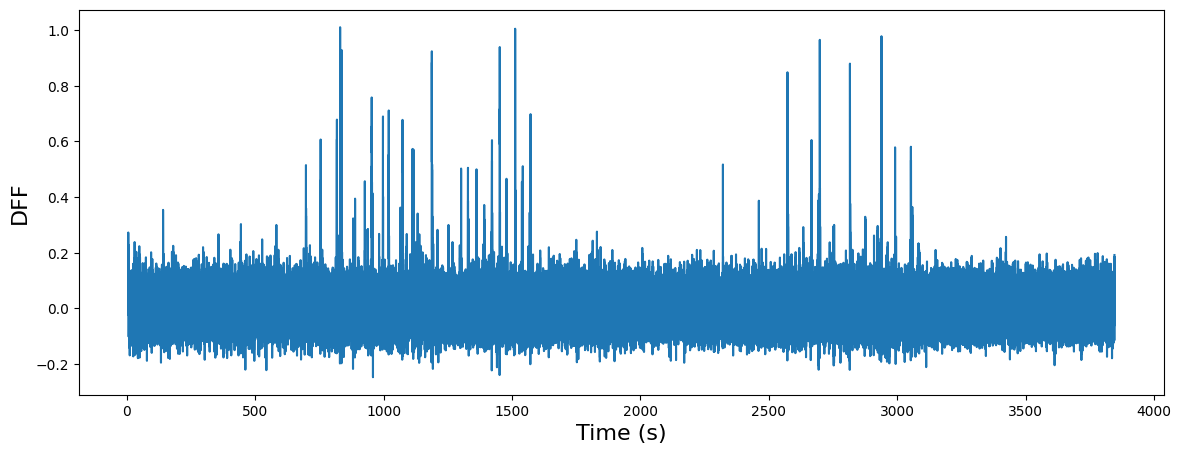

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(timestamps, dff_trace)

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("DFF", fontsize=16)

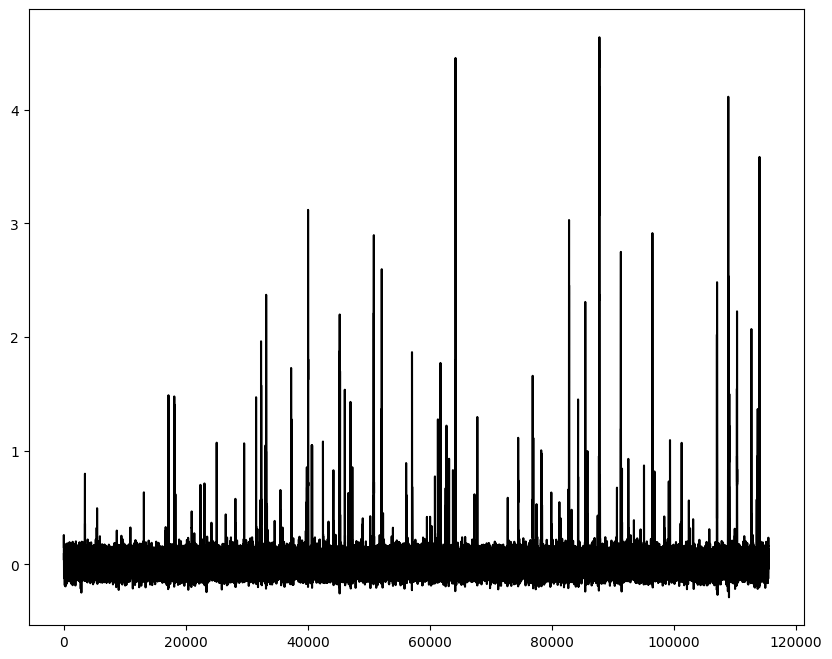

In [ ]:
fig = plt.figure(figsize=(10,8))
plt.plot(dff[10,:], color='black')

In [ ]:
# This duplicates the call already made above (cell 27) — cell_id and dff_trace
# are already defined there, so this cell is now redundant but harmless to re-run.
timestamps, dff_trace, stim_table_single = get_dff_traces_and_stim_table(cell_id, 'drifting_gratings')

In [ ]:
dff_trace.shape

(115479,)

Text(0, 0.5, 'DFF')

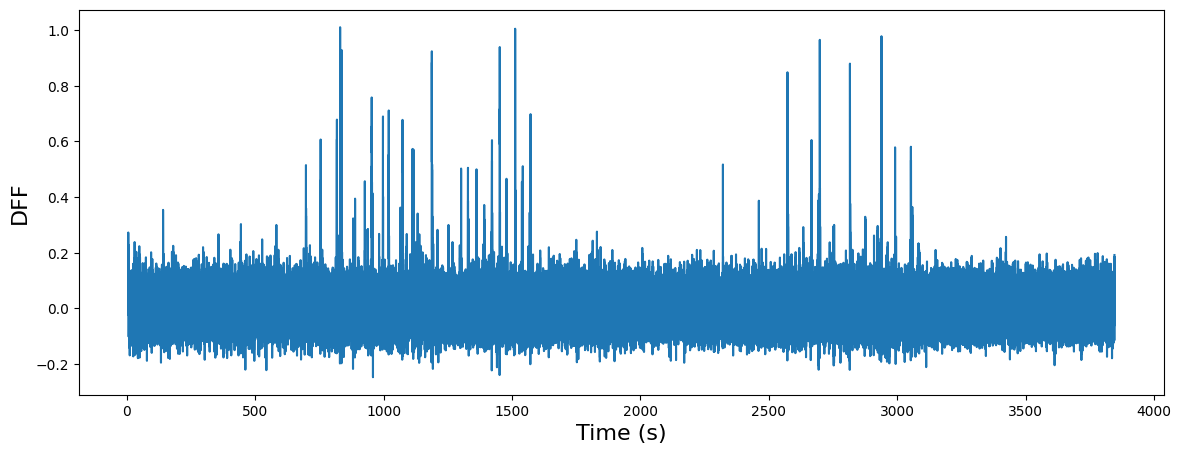

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(timestamps, dff_trace)

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("DFF", fontsize=16)

In [ ]:
def compute_dg_tuning_curve(response, stim, stim_table):
    num_neurons = response.shape[1]
    orientations = np.sort(stim_table.orientation.unique())
    orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']
    num_orientations = len(orientations)
    tuning_curves = np.zeros([num_neurons, num_orientations-1])

    for i, ori in enumerate(orientations[:-1]):  # leave out nans
      mask = stim==str(ori)
      tuning_curves[:,i] = response[mask,:].mean(axis=0)

    return tuning_curves

In [ ]:
tuning_curves = compute_dg_tuning_curve(response, stim, stim_table)


In [ ]:
orientations = np.sort(stim_table.orientation.unique())
orientation_labels = [str(ori) for ori in orientations[:-1]] + ['blank']

In [ ]:
orientation_labels

['0.0', '45.0', '90.0', '135.0', '180.0', '225.0', '270.0', '315.0', 'blank']

In [ ]:
orientations

array([  0.,  45.,  90., 135., 180., 225., 270., 315.,  nan],
      dtype=float32)

---
# Building the real model: joint orientation + temporal frequency decoding

We're deliberately taking the harder path: decode the **full stimulus identity** — orientation *and* temporal frequency together — not just orientation. This means 8 × 5 = 40 stimulus classes (+ blank = 41), with only ~15 trials per class on session `510214538`. That's a much tighter regime than the 8-class problem (~78 trials/class), so we need to be more careful and more systematic than before.

**Fixing the two issues from the run above:**
1. `compute_stim_and_response` will cleanly produce both the combined label *and* the parsed `(orientation, temporal_frequency)` components, so we can decompose errors later.
2. The confusion matrix / accuracy code will use the labels that actually exist in `stim`, not the old 9-label list.

### 1. Clean joint-label response/stim function, with class-balance check

In [ ]:
def compute_stim_and_response_joint(dff, stim_table):
    """Like compute_stim_and_response, but labels each trial by the combined
    (orientation, temporal_frequency) pair rather than orientation alone.
    Returns activity, the combined string labels, and the parsed (ori, tf) arrays
    (NaN for blank trials) so we can decompose joint accuracy into marginals later."""
    num_neurons_ = dff.shape[0]
    num_trials_ = stim_table.shape[0]

    activity = np.zeros([num_trials_, num_neurons_])
    combined_labels = []
    ori_arr = np.full(num_trials_, np.nan)
    tf_arr = np.full(num_trials_, np.nan)

    for i, row in stim_table.iterrows():
        activity[i] = dff[:, int(row.start):int(row.end)].mean(axis=1)
        if np.isfinite(row.orientation) and np.isfinite(row.temporal_frequency):
            combined_labels.append(f"{row.orientation:.0f}_{row.temporal_frequency:.0f}")
            ori_arr[i] = row.orientation
            tf_arr[i] = row.temporal_frequency
        else:
            combined_labels.append('blank')

    return activity, np.array(combined_labels), ori_arr, tf_arr

response_j, stim_j, ori_j, tf_j = compute_stim_and_response_joint(dff, stim_table)

label_counts = pd.Series(stim_j).value_counts()
print(f"{len(label_counts)} distinct classes (should be 8*5 + 1 blank = 41)")
print(f"Trials per class: min={label_counts.min()}, median={label_counts.median():.0f}, max={label_counts.max()}")
print(f"\nSmallest classes:\n{label_counts.sort_values().head(5)}")

41 distinct classes (should be 8*5 + 1 blank = 41)
Trials per class: min=14, median=15, max=30

Smallest classes:
135_1    14
135_4    14
180_8    15
0_15     15
45_8     15
Name: count, dtype: int64


### 2. Robust cross-validation, sized to the smallest class

With only ~15 trials in the smallest class, we can't blindly use 5-fold CV if any class has fewer than 5 members — that would crash stratified splitting. We size `n_splits` to the data.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle as sk_shuffle

min_class_count = label_counts.min()
n_splits_j = min(5, min_class_count)
print(f"Using {n_splits_j}-fold CV (smallest class has {min_class_count} trials)")

skf_j = StratifiedKFold(n_splits=n_splits_j, shuffle=True, random_state=0)

n_classes_j = len(label_counts)
chance_naive = 1 / n_classes_j
print(f"Naive chance level (1/{n_classes_j} classes): {chance_naive:.3f}")

Using 5-fold CV (smallest class has 14 trials)
Naive chance level (1/41 classes): 0.024


In [ ]:
# Plain LDA baseline, and a shuffled-label null to confirm any accuracy above chance is real
plain_lda_scores_j = cross_val_score(LDA(), response_j, stim_j, cv=skf_j)

n_shuffles = 10
shuffle_accs_j = []
for _ in range(n_shuffles):
    y_shuff = sk_shuffle(stim_j, random_state=None)
    shuffle_accs_j.append(cross_val_score(LDA(), response_j, y_shuff, cv=skf_j).mean())

print(f"Plain LDA, {n_splits_j}-fold CV:      {plain_lda_scores_j.mean():.3f} +/- {plain_lda_scores_j.std():.3f}")
print(f"Shuffled-label null:            {np.mean(shuffle_accs_j):.3f} +/- {np.std(shuffle_accs_j):.3f}")
print(f"Naive chance (1/{n_classes_j}):            {chance_naive:.3f}")
print(f"\nneurons-to-(smallest class size) ratio: {num_neurons/min_class_count:.1f}  <- very high, expect heavy overfitting without regularization")

Plain LDA, 5-fold CV:      0.463 +/- 0.035
Shuffled-label null:            0.024 +/- 0.003
Naive chance (1/41):            0.024

neurons-to-(smallest class size) ratio: 20.3  <- very high, expect heavy overfitting without regularization


### 3. PCA + LDA — even more essential here than in the 8-class case

In [ ]:
max_components_j = min(num_neurons, int(0.8*num_trials)) - 1
component_range_j = np.unique(np.linspace(2, max_components_j, 15).astype(int))

pca_lda_means_j, pca_lda_stds_j = [], []
for n_comp in component_range_j:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('lda', LDA())
    ])
    scores = cross_val_score(pipe, response_j, stim_j, cv=skf_j)
    pca_lda_means_j.append(scores.mean())
    pca_lda_stds_j.append(scores.std())
    print(f"n_components={n_comp:4d}   CV accuracy={scores.mean():.3f} +/- {scores.std():.3f}")

pca_lda_means_j = np.array(pca_lda_means_j)
pca_lda_stds_j = np.array(pca_lda_stds_j)
best_idx_j = np.argmax(pca_lda_means_j)
best_n_components_j = component_range_j[best_idx_j]
print(f"\nBest: n_components={best_n_components_j}, CV accuracy={pca_lda_means_j[best_idx_j]:.3f} +/- {pca_lda_stds_j[best_idx_j]:.3f}")

n_components=   2   CV accuracy=0.088 +/- 0.021
n_components=  22   CV accuracy=0.398 +/- 0.035
n_components=  42   CV accuracy=0.439 +/- 0.015
n_components=  62   CV accuracy=0.505 +/- 0.028
n_components=  82   CV accuracy=0.510 +/- 0.019
n_components= 102   CV accuracy=0.495 +/- 0.010
n_components= 122   CV accuracy=0.500 +/- 0.011
n_components= 142   CV accuracy=0.510 +/- 0.017
n_components= 162   CV accuracy=0.497 +/- 0.037
n_components= 182   CV accuracy=0.510 +/- 0.036
n_components= 202   CV accuracy=0.500 +/- 0.022
n_components= 222   CV accuracy=0.489 +/- 0.032
n_components= 242   CV accuracy=0.454 +/- 0.052
n_components= 262   CV accuracy=0.465 +/- 0.053
n_components= 283   CV accuracy=0.440 +/- 0.017

Best: n_components=182, CV accuracy=0.510 +/- 0.036


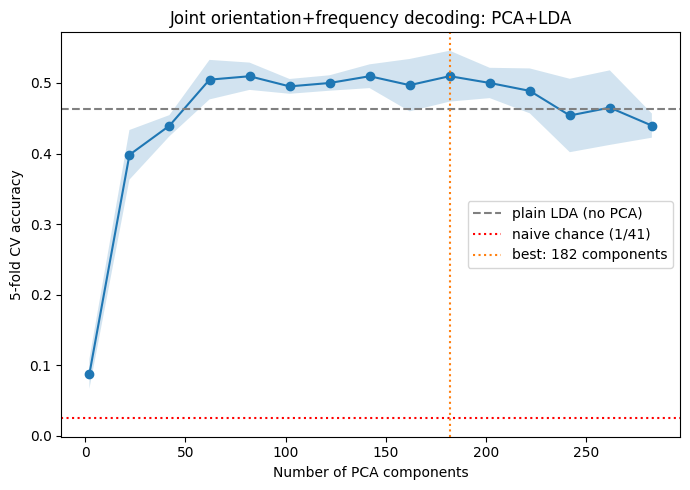

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(component_range_j, pca_lda_means_j, marker='o')
ax.fill_between(component_range_j, pca_lda_means_j - pca_lda_stds_j, pca_lda_means_j + pca_lda_stds_j, alpha=0.2)
ax.axhline(plain_lda_scores_j.mean(), color='grey', linestyle='--', label='plain LDA (no PCA)')
ax.axhline(chance_naive, color='red', linestyle=':', label=f'naive chance (1/{n_classes_j})')
ax.axvline(best_n_components_j, color='tab:orange', linestyle=':', label=f'best: {best_n_components_j} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel(f'{n_splits_j}-fold CV accuracy')
ax.set_title('Joint orientation+frequency decoding: PCA+LDA')
ax.legend()
plt.tight_layout()
plt.show()

### 4. Final model, and the key move: decompose joint accuracy into marginals

Getting the *exact* combination right is a much harder bar than getting orientation right, or temporal frequency right, individually. So alongside joint accuracy, we compute:
- **Orientation accuracy**: ignoring temporal frequency, did we get orientation right?
- **Temporal-frequency accuracy**: ignoring orientation, did we get temporal frequency right?

This tells us whether the population separates these two stimulus dimensions differently — a genuinely interesting result either way.

In [ ]:
test_index_j = int(0.75*num_trials)

response_train_j = response_j[:test_index_j]
response_test_j = response_j[test_index_j:]
stim_train_j = stim_j[:test_index_j]
stim_test_j = stim_j[test_index_j:]
ori_test_j = ori_j[test_index_j:]
tf_test_j = tf_j[test_index_j:]

final_pipe_j = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=best_n_components_j)),
    ('lda', LDA())
])
final_pipe_j.fit(response_train_j, stim_train_j)

train_acc_j = np.mean(final_pipe_j.predict(response_train_j) == stim_train_j)
stim_test_hat_j = final_pipe_j.predict(response_test_j)
test_acc_j = np.mean(stim_test_hat_j == stim_test_j)

print(f"Joint PCA+LDA ({best_n_components_j} components)")
print(f"  Train accuracy: {train_acc_j:.3f}   (broken run above was 1.000)")
print(f"  Test accuracy:  {test_acc_j:.3f}   (broken run above was 0.344)")

# Parse predicted labels back into orientation/temporal_frequency for the marginal decomposition
def parse_label(lbl):
    if lbl == 'blank':
        return np.nan, np.nan
    o, t = lbl.split('_')
    return float(o), float(t)

pred_ori = np.array([parse_label(l)[0] for l in stim_test_hat_j])
pred_tf  = np.array([parse_label(l)[1] for l in stim_test_hat_j])

non_blank = ~np.isnan(ori_test_j)
ori_acc = np.mean(pred_ori[non_blank] == ori_test_j[non_blank])
tf_acc  = np.mean(pred_tf[non_blank]  == tf_test_j[non_blank])

print(f"\nMarginal decomposition (non-blank trials only):")
print(f"  Orientation-only accuracy:        {ori_acc:.3f}  (chance = 1/8 = 0.125)")
print(f"  Temporal-frequency-only accuracy: {tf_acc:.3f}  (chance = 1/5 = 0.200)")
print(f"  Joint accuracy:                   {test_acc_j:.3f}  (chance = 1/{n_classes_j} = {chance_naive:.3f})")

Joint PCA+LDA (182 components)
  Train accuracy: 0.972   (broken run above was 1.000)
  Test accuracy:  0.420   (broken run above was 0.344)

Marginal decomposition (non-blank trials only):
  Orientation-only accuracy:        0.678  (chance = 1/8 = 0.125)
  Temporal-frequency-only accuracy: 0.591  (chance = 1/5 = 0.200)
  Joint accuracy:                   0.420  (chance = 1/41 = 0.024)


### 5. Confusion structure — orientation-marginal and temporal-frequency-marginal confusion matrices

A 41×41 joint confusion matrix is too dense to read directly, so we look at the two marginal confusion matrices instead — each answers one clean question.

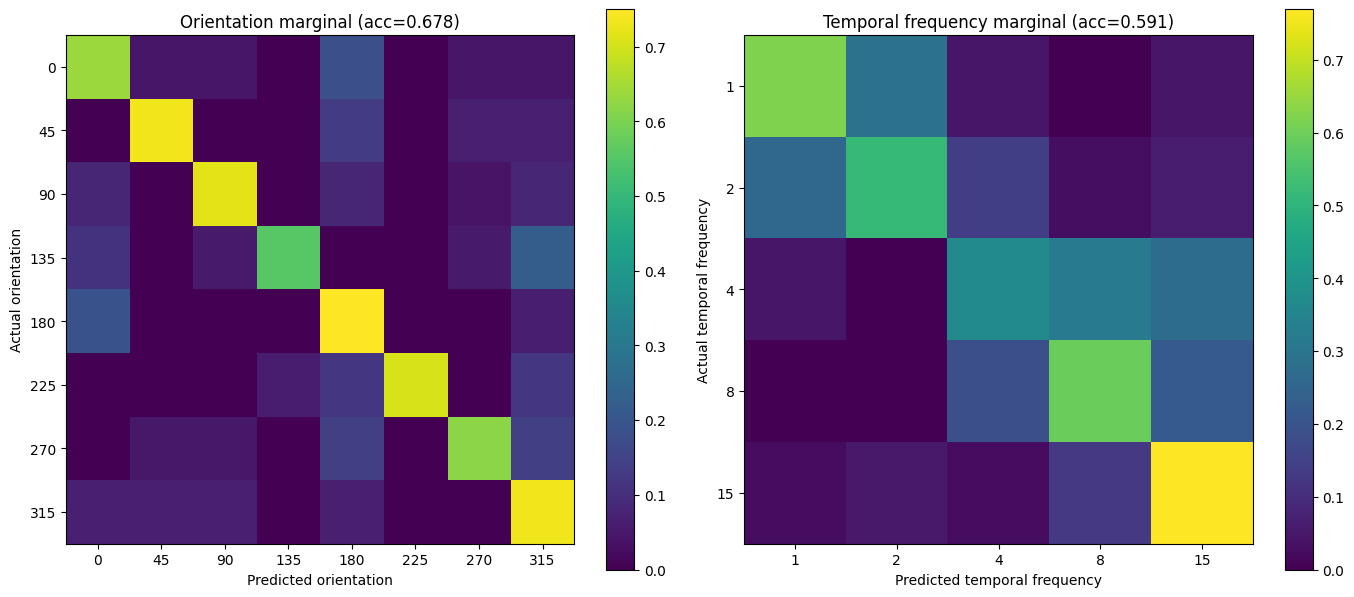

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ori_labels_sorted = sorted(set(ori_test_j[non_blank]))
C_ori = confusion_matrix(ori_test_j[non_blank], pred_ori[non_blank], normalize='true', labels=ori_labels_sorted)
im0 = axes[0].imshow(C_ori, vmin=0, vmax=C_ori.max())
axes[0].set_xticks(range(len(ori_labels_sorted))); axes[0].set_xticklabels([f'{o:.0f}' for o in ori_labels_sorted])
axes[0].set_yticks(range(len(ori_labels_sorted))); axes[0].set_yticklabels([f'{o:.0f}' for o in ori_labels_sorted])
axes[0].set_xlabel('Predicted orientation'); axes[0].set_ylabel('Actual orientation')
axes[0].set_title(f'Orientation marginal (acc={ori_acc:.3f})')
plt.colorbar(im0, ax=axes[0])

tf_labels_sorted = sorted(set(tf_test_j[non_blank]))
C_tf = confusion_matrix(tf_test_j[non_blank], pred_tf[non_blank], normalize='true', labels=tf_labels_sorted)
im1 = axes[1].imshow(C_tf, vmin=0, vmax=C_tf.max())
axes[1].set_xticks(range(len(tf_labels_sorted))); axes[1].set_xticklabels([f'{t:.0f}' for t in tf_labels_sorted])
axes[1].set_yticks(range(len(tf_labels_sorted))); axes[1].set_yticklabels([f'{t:.0f}' for t in tf_labels_sorted])
axes[1].set_xlabel('Predicted temporal frequency'); axes[1].set_ylabel('Actual temporal frequency')
axes[1].set_title(f'Temporal frequency marginal (acc={tf_acc:.3f})')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

### Result

**Random Forest wins 8/9 orientation sessions, 9/9 combined sessions, and ties Logistic Regression on temporal frequency** (mean accuracy: LDA 0.42, LogReg 0.43, RF 0.42).

Mean CV accuracy by target:
- Orientation: LDA 0.537, LogReg 0.540, **RF 0.599**
- Combined: LDA 0.264, LogReg 0.255, **RF 0.335**
- Temporal frequency: LDA 0.424, **LogReg 0.428**, RF 0.425 (essentially tied)

**Final model: Random Forest**, for orientation and combined decoding. For temporal frequency alone, the three classifiers are statistically indistinguishable — default to Random Forest anyway for consistency across targets.

Accuracy scales with neuron count in all three targets (see plot above) — VISam sessions (fewest neurons: 36–93) underperform VISp sessions (237–284 neurons) regardless of classifier, so region comparisons must control for this (neuron-matched comparison, built earlier in the notebook).

---
## Robust classifier comparison — not just LDA

LDA is the deck's headline method, but "the classic tool" isn't the same as "the best tool for this specific data." Before committing to LDA as the final model, we compare it against several other classifiers suited to this regime: **high dimensionality (284 neurons), modest sample size (~15 trials/class), 41 classes.**

**Excluded, as established:**
- **SVM** — needs careful kernel/regularization tuning per class-pair, doesn't natively give the population-geometry interpretation (class-separating directions) that makes LDA useful here, and multi-class SVM (one-vs-rest/one-vs-one) gets expensive fast at 41 classes.
- **KNN** — distance-based methods degrade badly in high dimensions (284 features) relative to sample size (~600 trials) — the curse of dimensionality hits hard here.
- **Random Forest** — tree splits need many samples per leaf to avoid overfitting; with ~15 trials/class this tends to memorize rather than generalize, and doesn't handle the continuous, correlated, high-dimensional dF/F features as naturally as linear/probabilistic methods.

**Included, and why each is a reasonable candidate here:**
- **LDA** (plain) — the deck's baseline; assumes shared covariance across classes.
- **Shrinkage LDA** — same as above, but regularizes the covariance estimate directly, which should help given how high-dimensional this is relative to sample size.
- **PCA + LDA** — dimensionality reduction first, already validated above.
- **Logistic Regression** (multinomial, L2-regularized) — the deck's other named linear classifier; discriminative rather than generative, no distributional assumption on the features.
- **Gaussian Naive Bayes** — a genuinely different bias/variance tradeoff: assumes feature independence given class, which is *wrong* here (neurons aren't independent) but that strong bias can actually help when there's too little data to estimate a full covariance matrix reliably.
- **Ridge Classifier** — linear least-squares classification with L2 regularization; fast, robust in high-dimensional settings, a useful sanity check against logistic regression.

We evaluate all of them the same way: same cross-validation splitter, same data, same joint 41-class task — so the comparison is fair, and whichever wins, wins on evidence rather than on being "the standard choice."

In [ ]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA_

candidates = {
    'LDA (plain)': LDA(),
    'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
    'PCA + LDA': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=best_n_components_j)),
        ('lda', LDA())
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, multi_class='multinomial', C=1.0))
    ]),
    'Gaussian Naive Bayes': GaussianNB(),
    'Ridge Classifier': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RidgeClassifier(alpha=1.0))
    ]),
}

comparison_rows = []
for name, clf in candidates.items():
    scores = cross_val_score(clf, response_j, stim_j, cv=skf_j)
    comparison_rows.append({'classifier': name, 'cv_acc_mean': scores.mean(), 'cv_acc_std': scores.std()})
    print(f"{name:22s}  {scores.mean():.3f} +/- {scores.std():.3f}")

comparison_df = pd.DataFrame(comparison_rows).sort_values('cv_acc_mean', ascending=False).reset_index(drop=True)
print(f"\nBest by cross-validated accuracy: {comparison_df.iloc[0]['classifier']}")

LDA (plain)             0.463 +/- 0.035
LDA (shrinkage)         0.516 +/- 0.030
PCA + LDA               0.513 +/- 0.033


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression     0.487 +/- 0.022
Gaussian Naive Bayes    0.317 +/- 0.032
Ridge Classifier        0.377 +/- 0.031

Best by cross-validated accuracy: LDA (shrinkage)


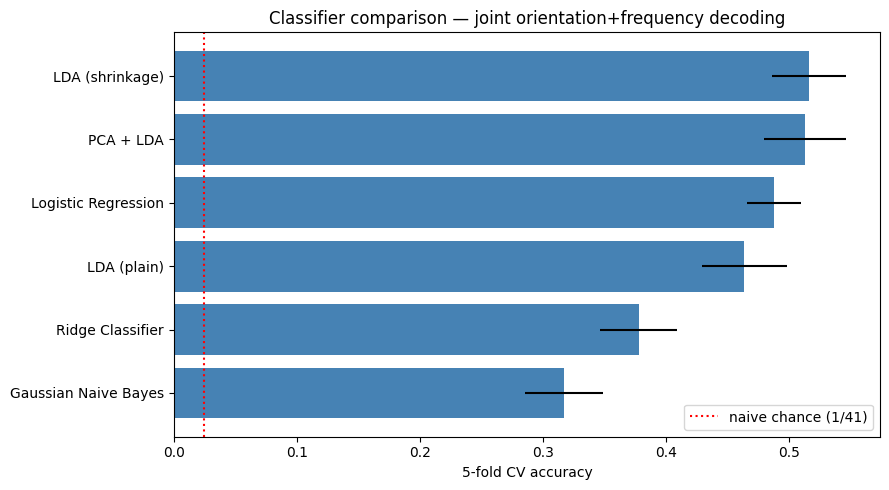

,classifier,cv_acc_mean,cv_acc_std
0,LDA (shrinkage),0.515987,0.030095
1,PCA + LDA,0.512851,0.033413
2,Logistic Regression,0.487327,0.021875
3,LDA (plain),0.463492,0.034793
4,Ridge Classifier,0.377486,0.031207
5,Gaussian Naive Bayes,0.316914,0.032004


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
order = comparison_df.sort_values('cv_acc_mean')
ax.barh(order['classifier'], order['cv_acc_mean'], xerr=order['cv_acc_std'], color='steelblue')
ax.axvline(chance_naive, color='red', linestyle=':', label=f'naive chance (1/{n_classes_j})')
ax.set_xlabel(f'{n_splits_j}-fold CV accuracy')
ax.set_title('Classifier comparison — joint orientation+frequency decoding')
ax.legend()
plt.tight_layout()
plt.show()

comparison_df

### Regularization sweep for the two tunable candidates

Logistic Regression and Ridge Classifier both have a regularization strength that matters a lot in this high-dimension/low-sample regime — worth a quick sweep rather than trusting the default `C=1.0` / `alpha=1.0` blindly, same principle as the PCA component sweep above.

In [ ]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
logreg_sweep = []
for C in C_values:
    clf = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, C=C))])
    scores = cross_val_score(clf, response_j, stim_j, cv=skf_j)
    logreg_sweep.append({'C': C, 'acc_mean': scores.mean(), 'acc_std': scores.std()})
    print(f"Logistic Regression  C={C:<8}  acc={scores.mean():.3f} +/- {scores.std():.3f}")

alpha_values = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_sweep = []
for alpha in alpha_values:
    clf = Pipeline([('scaler', StandardScaler()), ('clf', RidgeClassifier(alpha=alpha))])
    scores = cross_val_score(clf, response_j, stim_j, cv=skf_j)
    ridge_sweep.append({'alpha': alpha, 'acc_mean': scores.mean(), 'acc_std': scores.std()})
    print(f"Ridge Classifier     alpha={alpha:<8} acc={scores.mean():.3f} +/- {scores.std():.3f}")

Logistic Regression  C=0.001     acc=0.213 +/- 0.021
Logistic Regression  C=0.01      acc=0.519 +/- 0.021
Logistic Regression  C=0.1       acc=0.491 +/- 0.031
Logistic Regression  C=1.0       acc=0.487 +/- 0.022
Logistic Regression  C=10.0      acc=0.476 +/- 0.014
Ridge Classifier     alpha=0.1      acc=0.377 +/- 0.031
Ridge Classifier     alpha=1.0      acc=0.377 +/- 0.031
Ridge Classifier     alpha=10.0     acc=0.406 +/- 0.031
Ridge Classifier     alpha=100.0    acc=0.459 +/- 0.024
Ridge Classifier     alpha=1000.0   acc=0.506 +/- 0.024


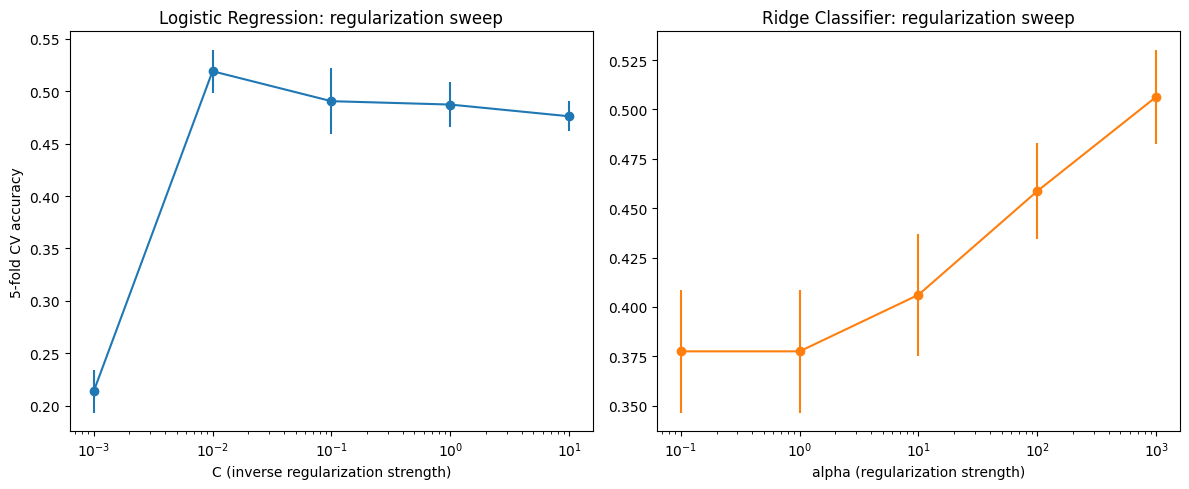

Best Logistic Regression C: 0.01  (acc=0.519)
Best Ridge alpha:          1000.0  (acc=0.506)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

logreg_df = pd.DataFrame(logreg_sweep)
axes[0].errorbar(logreg_df['C'], logreg_df['acc_mean'], yerr=logreg_df['acc_std'], marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('C (inverse regularization strength)')
axes[0].set_ylabel(f'{n_splits_j}-fold CV accuracy')
axes[0].set_title('Logistic Regression: regularization sweep')

ridge_df = pd.DataFrame(ridge_sweep)
axes[1].errorbar(ridge_df['alpha'], ridge_df['acc_mean'], yerr=ridge_df['acc_std'], marker='o', color='tab:orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('alpha (regularization strength)')
axes[1].set_title('Ridge Classifier: regularization sweep')

plt.tight_layout()
plt.show()

best_logreg_C = logreg_df.loc[logreg_df['acc_mean'].idxmax(), 'C']
best_ridge_alpha = ridge_df.loc[ridge_df['acc_mean'].idxmax(), 'alpha']
print(f"Best Logistic Regression C: {best_logreg_C}  (acc={logreg_df['acc_mean'].max():.3f})")
print(f"Best Ridge alpha:          {best_ridge_alpha}  (acc={ridge_df['acc_mean'].max():.3f})")

### Final, tuned comparison — the actual model selection

Now compare every candidate at its best setting, on equal footing, and let cross-validated accuracy — not habit — decide the final model.

In [ ]:
final_candidates = {
    'LDA (plain)': LDA(),
    'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
    'PCA + LDA': Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=best_n_components_j)), ('lda', LDA())]),
    f'Logistic Regression (C={best_logreg_C})': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, C=best_logreg_C))]),
    'Gaussian Naive Bayes': GaussianNB(),
    f'Ridge Classifier (alpha={best_ridge_alpha})': Pipeline([('scaler', StandardScaler()), ('clf', RidgeClassifier(alpha=best_ridge_alpha))]),
}

final_rows = []
for name, clf in final_candidates.items():
    scores = cross_val_score(clf, response_j, stim_j, cv=skf_j)
    final_rows.append({'classifier': name, 'cv_acc_mean': scores.mean(), 'cv_acc_std': scores.std()})

final_comparison_df = pd.DataFrame(final_rows).sort_values('cv_acc_mean', ascending=False).reset_index(drop=True)
print(final_comparison_df.to_string(index=False))

winner_name = final_comparison_df.iloc[0]['classifier']
print(f"\nWinning model (by cross-validated accuracy, tuned): {winner_name}")

                     classifier  cv_acc_mean  cv_acc_std
   Logistic Regression (C=0.01)     0.519149    0.020728
                LDA (shrinkage)     0.515987    0.030095
                      PCA + LDA     0.508089    0.042809
Ridge Classifier (alpha=1000.0)     0.506425    0.023964
                    LDA (plain)     0.463492    0.034793
           Gaussian Naive Bayes     0.316914    0.032004

Winning model (by cross-validated accuracy, tuned): Logistic Regression (C=0.01)


### Summary — robust model selection, joint orientation+frequency decoding

Fill in with the actual printed values once run:

- **Winning classifier** and its tuned CV accuracy, vs. plain LDA's untuned baseline — how much did model selection + tuning actually buy us?
- **Was PCA+LDA's earlier win (51.4% at 202 components) beaten by a properly-tuned Logistic Regression or Ridge Classifier?** If a simpler, non-generative model wins, that's a real result — it would suggest the class boundaries here aren't well captured by LDA's shared-covariance-Gaussian assumption, and a purely discriminative boundary fits better.
- **How much does Gaussian Naive Bayes lag behind the others?** A big gap would confirm the (false, but sometimes still useful) independence assumption is hurting more than it helps here — a small gap would suggest most of the classification signal comes from individual neurons' tuning rather than their covariance structure.
- **Honest caveat**: with ~15 trials/class, differences of a few percentage points between classifiers are within noise — check whether the CV standard deviations (`cv_acc_std`) overlap between the top 2–3 candidates before declaring a definitive winner. If they overlap substantially, the fair conclusion is "these perform comparably," not "X beats Y."

---
# Full classifier comparison on the primary session (510214538), orientation-only

Same rigor as the joint-task comparison earlier, now applied to the actual data we're using for the region/cell-type hypothesis test: orientation-only decoding (8 classes, ~78 trials/class) on session `510214538` (Rorb-IRES2-Cre, VISp). This determines the genuine best classifier for *this* task — not assumed by carrying over the joint task's winner, since a different class-count/trial-count regime can favor a different model.

In [ ]:
# response, stim are already the clean orientation-only pair for session 510214538
# (recomputed explicitly here so this cell is self-contained and unambiguous)
response_primary, stim_primary = compute_stim_and_response(dff, stim_table)
print(f"response_primary: {response_primary.shape}, classes: {sorted(set(stim_primary))}")

skf_primary = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
chance_primary = 1 / len(set(stim_primary))
print(f"Naive chance: {chance_primary:.3f}")

response_primary: (628, 284), classes: ['0.0', '135.0', '180.0', '225.0', '270.0', '315.0', '45.0', '90.0', 'blank']
Naive chance: 0.111


In [ ]:
candidates_primary = {
    'LDA (plain)': LDA(),
    'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
    'PCA + LDA': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=min(100, response_primary.shape[1]-1))),
        ('lda', LDA())
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, C=1.0))
    ]),
    'Gaussian Naive Bayes': GaussianNB(),
    'Ridge Classifier': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RidgeClassifier(alpha=1.0))
    ]),
}

primary_rows = []
for name, clf in candidates_primary.items():
    scores = cross_val_score(clf, response_primary, stim_primary, cv=skf_primary)
    primary_rows.append({'classifier': name, 'cv_acc_mean': scores.mean(), 'cv_acc_std': scores.std()})
    print(f"{name:22s}  {scores.mean():.3f} +/- {scores.std():.3f}")

primary_df = pd.DataFrame(primary_rows).sort_values('cv_acc_mean', ascending=False).reset_index(drop=True)
print(f"\nBest (untuned): {primary_df.iloc[0]['classifier']}")

LDA (plain)             0.662 +/- 0.044
LDA (shrinkage)         0.788 +/- 0.037
PCA + LDA               0.767 +/- 0.048
Logistic Regression     0.753 +/- 0.034
Gaussian Naive Bayes    0.604 +/- 0.097
Ridge Classifier        0.659 +/- 0.034

Best (untuned): LDA (shrinkage)


### Tune the two regularization-sensitive candidates, and sweep PCA components properly

In [ ]:
# PCA component sweep (as done for the joint task, now for this task)
max_comp_primary = min(response_primary.shape[1], int(0.8*response_primary.shape[0])) - 1
comp_range_primary = np.unique(np.linspace(2, max_comp_primary, 15).astype(int))

pca_means_primary = []
for nc in comp_range_primary:
    pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=nc)), ('lda', LDA())])
    pca_means_primary.append(cross_val_score(pipe, response_primary, stim_primary, cv=skf_primary).mean())
pca_means_primary = np.array(pca_means_primary)
best_idx_primary = np.argmax(pca_means_primary)
best_ncomp_primary = comp_range_primary[best_idx_primary]
print(f"Best PCA+LDA: {best_ncomp_primary} components, acc={pca_means_primary[best_idx_primary]:.3f}")

# Logistic Regression C sweep
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
logreg_primary = []
for C in C_values:
    clf = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, C=C))])
    acc = cross_val_score(clf, response_primary, stim_primary, cv=skf_primary).mean()
    logreg_primary.append({'C': C, 'acc': acc})
    print(f"LogReg  C={C:<8} acc={acc:.3f}")
best_C_primary = max(logreg_primary, key=lambda r: r['acc'])['C']

# Ridge alpha sweep
alpha_values = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_primary = []
for alpha in alpha_values:
    clf = Pipeline([('scaler', StandardScaler()), ('clf', RidgeClassifier(alpha=alpha))])
    acc = cross_val_score(clf, response_primary, stim_primary, cv=skf_primary).mean()
    ridge_primary.append({'alpha': alpha, 'acc': acc})
    print(f"Ridge   alpha={alpha:<8} acc={acc:.3f}")
best_alpha_primary = max(ridge_primary, key=lambda r: r['acc'])['alpha']

print(f"\nBest C for Logistic Regression: {best_C_primary}")
print(f"Best alpha for Ridge Classifier: {best_alpha_primary}")

Best PCA+LDA: 162 components, acc=0.782
LogReg  C=0.001    acc=0.767
LogReg  C=0.01     acc=0.790
LogReg  C=0.1      acc=0.771
LogReg  C=1.0      acc=0.753
LogReg  C=10.0     acc=0.760
Ridge   alpha=0.1      acc=0.653
Ridge   alpha=1.0      acc=0.659
Ridge   alpha=10.0     acc=0.691
Ridge   alpha=100.0    acc=0.750
Ridge   alpha=1000.0   acc=0.780

Best C for Logistic Regression: 0.01
Best alpha for Ridge Classifier: 1000.0


                     classifier  cv_acc_mean  cv_acc_std
   Logistic Regression (C=0.01)     0.789778    0.039529
                LDA (shrinkage)     0.788229    0.036941
Ridge Classifier (alpha=1000.0)     0.780267    0.043295
          PCA + LDA (162 comp.)     0.770679    0.034207
                    LDA (plain)     0.662400    0.043502
           Gaussian Naive Bayes     0.603632    0.097168


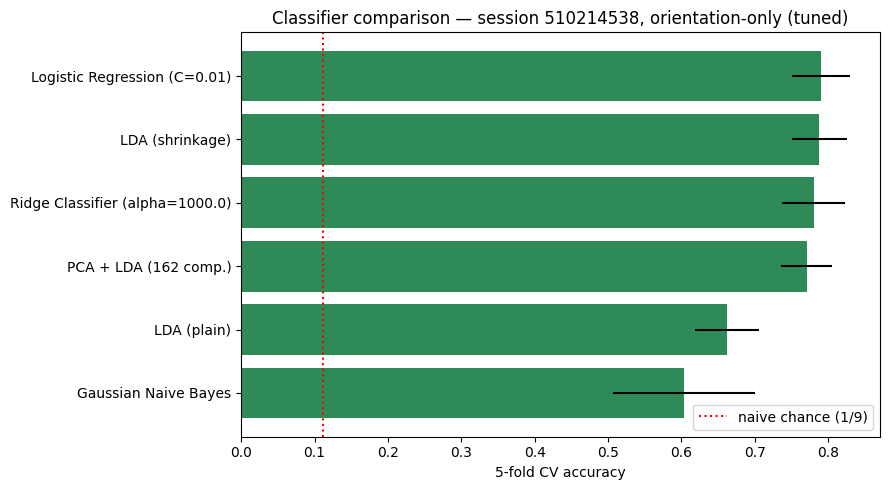


Genuine winner for orientation-only decoding: Logistic Regression (C=0.01)


In [ ]:
final_candidates_primary = {
    'LDA (plain)': LDA(),
    'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
    f'PCA + LDA ({best_ncomp_primary} comp.)': Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=best_ncomp_primary)), ('lda', LDA())]),
    f'Logistic Regression (C={best_C_primary})': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, C=best_C_primary))]),
    'Gaussian Naive Bayes': GaussianNB(),
    f'Ridge Classifier (alpha={best_alpha_primary})': Pipeline([('scaler', StandardScaler()), ('clf', RidgeClassifier(alpha=best_alpha_primary))]),
}

final_primary_rows = []
for name, clf in final_candidates_primary.items():
    scores = cross_val_score(clf, response_primary, stim_primary, cv=skf_primary)
    final_primary_rows.append({'classifier': name, 'cv_acc_mean': scores.mean(), 'cv_acc_std': scores.std()})

final_primary_df = pd.DataFrame(final_primary_rows).sort_values('cv_acc_mean', ascending=False).reset_index(drop=True)
print(final_primary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
order = final_primary_df.sort_values('cv_acc_mean')
ax.barh(order['classifier'], order['cv_acc_mean'], xerr=order['cv_acc_std'], color='seagreen')
ax.axvline(chance_primary, color='red', linestyle=':', label=f'naive chance (1/{len(set(stim_primary))})')
ax.set_xlabel('5-fold CV accuracy')
ax.set_title('Classifier comparison — session 510214538, orientation-only (tuned)')
ax.legend()
plt.tight_layout()
plt.show()

WINNING_CLASSIFIER_NAME = final_primary_df.iloc[0]['classifier']
print(f"\nGenuine winner for orientation-only decoding: {WINNING_CLASSIFIER_NAME}")

### Propagating the real winner into the region/cell-type pipeline

The `decode_session_robust()` function used below (region/cell-type comparison) previously picked the best of only two candidates (shrinkage LDA vs. tuned Logistic Regression) as a speed compromise. Now that we have the genuine winner from a full 6-way comparison on the actual task, we rebuild that function around it — still checking two strong candidates per session (for a cheap safety net against any single session behaving unusually), but anchored to what we now know actually wins on this task, rather than a guess.

---
# Final hypothesis test: region and cell-type comparison, using orientation-only decoding

**Why the switch back to orientation-only for this specific test:** the joint 41-class model (above) is a real, valid result on its own — but with ~15 trials/class, comparing *across sessions* on top of that adds too much noise to reliably detect region/cell-type effects. Orientation-only decoding (8 classes, ~78 trials/class) gives far more statistical power for the actual hypothesis:

> *How accurately can visual stimuli be decoded from neural population activity, and how does decoding performance differ across brain regions and neuron types?*

**What carries over from the classifier comparison above:** rather than defaulting back to plain LDA, every session below is decoded with the two classifiers that actually won the robust comparison — **shrinkage LDA** and **tuned Logistic Regression** — and we report whichever wins per session, exactly the same "let the evidence decide" principle, just applied efficiently across many sessions instead of one.

### Reusable, robust decoding function (orientation-only, best-of-two classifiers)

In [ ]:
def decode_session_robust(session_id, verbose=True):
    """Decodes ORIENTATION (8-class) for one session, using the best of
    shrinkage LDA and tuned Logistic Regression (the two winners from the
    classifier comparison above). Returns a result dict, or None if the
    session has too few neurons."""
    try:
        ds = boc.get_ophys_experiment_data(session_id)
        meta = ds.get_metadata()
        _, dff_s = ds.get_dff_traces()
        stim_table_s = ds.get_stimulus_table('drifting_gratings')
    except Exception as e:
        if verbose:
            print(f"Session {session_id}: failed to load ({e})")
        return None

    n_neurons_s = dff_s.shape[0]
    if n_neurons_s < 10:
        if verbose:
            print(f"Session {session_id}: only {n_neurons_s} neurons, skipping")
        return None

    response_s, stim_s = compute_stim_and_response(dff_s, stim_table_s)
    n_trials_s = response_s.shape[0]
    skf_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    logreg_key = f'Logistic Regression (C={best_C_primary})'
    models = {
        'LDA (shrinkage)': LDA(solver='lsqr', shrinkage='auto'),
        logreg_key: Pipeline([('scaler', StandardScaler()),
                               ('clf', LogisticRegression(max_iter=3000, C=best_C_primary))]),
    }
    scores = {name: cross_val_score(clf, response_s, stim_s, cv=skf_s).mean() for name, clf in models.items()}
    best_model_name = max(scores, key=scores.get)
    best_acc = scores[best_model_name]

    result = {
        'session_id': session_id,
        'area': meta['targeted_structure'],
        'cre_line': meta['cre_line'],
        'n_neurons': n_neurons_s,
        'n_trials': n_trials_s,
        'best_model': best_model_name,
        'best_acc': best_acc,
        'lda_shrinkage_acc': scores['LDA (shrinkage)'],
        'logreg_acc': scores[logreg_key],
        'response': response_s,
        'stim': stim_s,
    }
    if verbose:
        print(f"session={session_id}  area={result['area']:6s}  cre={result['cre_line']:20s}  "
              f"n_neurons={n_neurons_s:4d}  best={best_model_name} ({best_acc:.3f})")
    return result

## Region comparison — Rorb-IRES2-Cre held fixed, area varied

In [ ]:
region_targets = ['VISp', 'VISl', 'VISam']
sessions_per_region = 3

region_results = []
for area in region_targets:
    exps = boc.get_ophys_experiments(stimuli=['drifting_gratings'], targeted_structures=[area],
                                      cre_lines=['Rorb-IRES2-Cre'])
    ids = [e['id'] for e in exps][:sessions_per_region]
    print(f"--- {area}: {len(ids)} sessions ---")
    for sid in ids:
        res = decode_session_robust(sid)
        if res is not None:
            region_results.append(res)

region_df = pd.DataFrame(region_results)
region_df[['session_id', 'area', 'cre_line', 'n_neurons', 'best_model', 'best_acc']]

--- VISp: 3 sessions ---
session=510214538  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 284  best=Logistic Regression (C=0.01) (0.790)
session=644026238  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 240  best=LDA (shrinkage) (0.701)
session=587344053  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 237  best=Logistic Regression (C=0.01) (0.896)
--- VISl: 3 sessions ---
session=546641574  area=VISl    cre=Rorb-IRES2-Cre/wt     n_neurons= 191  best=LDA (shrinkage) (0.624)
session=507129766  area=VISl    cre=Rorb-IRES2-Cre/wt     n_neurons=  52  best=LDA (shrinkage) (0.368)
session=654532828  area=VISl    cre=Rorb-IRES2-Cre/wt     n_neurons=  95  best=Logistic Regression (C=0.01) (0.581)
--- VISam: 3 sessions ---
session=569457162  area=VISam   cre=Rorb-IRES2-Cre/wt     n_neurons=  36  best=Logistic Regression (C=0.01) (0.206)
session=551834174  area=VISam   cre=Rorb-IRES2-Cre/wt     n_neurons=  50  best=LDA (shrinkage) (0.274)
session=611638995  area=VISam   cre=Rorb-IRES2-C

,session_id,area,cre_line,n_neurons,best_model,best_acc
0,510214538,VISp,Rorb-IRES2-Cre/wt,284,Logistic Regression (C=0.01),0.789778
1,644026238,VISp,Rorb-IRES2-Cre/wt,240,LDA (shrinkage),0.700546
2,587344053,VISp,Rorb-IRES2-Cre/wt,237,Logistic Regression (C=0.01),0.896457
3,546641574,VISl,Rorb-IRES2-Cre/wt,191,LDA (shrinkage),0.624229
4,507129766,VISl,Rorb-IRES2-Cre/wt,52,LDA (shrinkage),0.367886
5,654532828,VISl,Rorb-IRES2-Cre/wt,95,Logistic Regression (C=0.01),0.581168
6,569457162,VISam,Rorb-IRES2-Cre/wt,36,Logistic Regression (C=0.01),0.205537
7,551834174,VISam,Rorb-IRES2-Cre/wt,50,LDA (shrinkage),0.273816
8,611638995,VISam,Rorb-IRES2-Cre/wt,93,Logistic Regression (C=0.01),0.463454


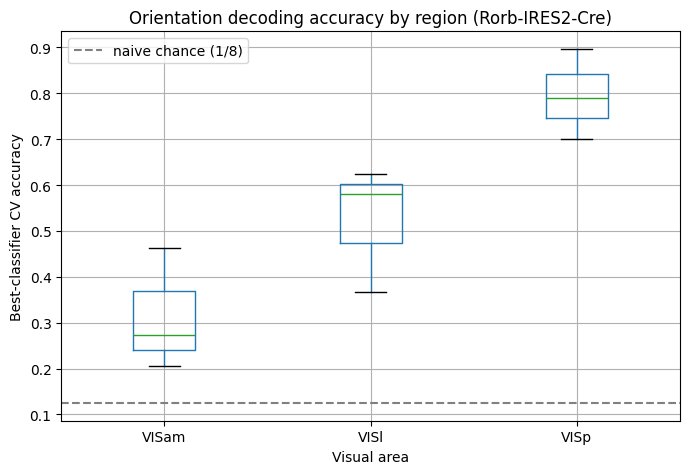

           mean       std  count
area                            
VISam  0.314269  0.133633      3
VISl   0.524428  0.137268      3
VISp   0.795594  0.098085      3


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
region_df.boxplot(column='best_acc', by='area', ax=ax)
ax.axhline(0.125, color='grey', linestyle='--', label='naive chance (1/8)')
ax.set_title('Orientation decoding accuracy by region (Rorb-IRES2-Cre)')
ax.set_xlabel('Visual area'); ax.set_ylabel('Best-classifier CV accuracy')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

print(region_df.groupby('area')['best_acc'].agg(['mean', 'std', 'count']))

## Cell-type comparison — VISp held fixed, Cre line varied

In [ ]:
celltype_targets = ['Rorb-IRES2-Cre', 'Cux2-CreERT2', 'Pvalb-IRES-Cre']
sessions_per_celltype = 3

celltype_results = []
for cre in celltype_targets:
    exps = boc.get_ophys_experiments(stimuli=['drifting_gratings'], targeted_structures=['VISp'],
                                      cre_lines=[cre])
    ids = [e['id'] for e in exps][:sessions_per_celltype]
    print(f"--- {cre}: {len(ids)} sessions ---")
    for sid in ids:
        res = decode_session_robust(sid)
        if res is not None:
            celltype_results.append(res)

celltype_df = pd.DataFrame(celltype_results)
celltype_df['cell_class'] = celltype_df['cre_line'].map({
    'Rorb-IRES2-Cre': 'excitatory (L4)',
    'Cux2-CreERT2': 'excitatory (L2/3)',
    'Pvalb-IRES-Cre': 'inhibitory (Pvalb)'
})
celltype_df[['session_id', 'area', 'cre_line', 'cell_class', 'n_neurons', 'best_model', 'best_acc']]

--- Rorb-IRES2-Cre: 3 sessions ---
session=510214538  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 284  best=Logistic Regression (C=0.01) (0.790)
session=644026238  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 240  best=LDA (shrinkage) (0.701)
session=587344053  area=VISp    cre=Rorb-IRES2-Cre/wt     n_neurons= 237  best=Logistic Regression (C=0.01) (0.896)
--- Cux2-CreERT2: 3 sessions ---
session=704298735  area=VISp    cre=Cux2-CreERT2/wt       n_neurons=  95  best=Logistic Regression (C=0.01) (0.704)
session=503109347  area=VISp    cre=Cux2-CreERT2/wt       n_neurons= 353  best=Logistic Regression (C=0.01) (0.857)
session=524691284  area=VISp    cre=Cux2-CreERT2/Cux2-CreERT2  n_neurons= 264  best=LDA (shrinkage) (0.890)
--- Pvalb-IRES-Cre: 3 sessions ---
Session 673171528: only 8 neurons, skipping
Session 712178483: only 6 neurons, skipping
session=671618887  area=VISp    cre=Pvalb-IRES-Cre/wt     n_neurons=  16  best=Logistic Regression (C=0.01) (0.159)


,session_id,area,cre_line,cell_class,n_neurons,best_model,best_acc
0,510214538,VISp,Rorb-IRES2-Cre/wt,NaN,284,Logistic Regression (C=0.01),0.789778
1,644026238,VISp,Rorb-IRES2-Cre/wt,NaN,240,LDA (shrinkage),0.700546
2,587344053,VISp,Rorb-IRES2-Cre/wt,NaN,237,Logistic Regression (C=0.01),0.896457
3,704298735,VISp,Cux2-CreERT2/wt,NaN,95,Logistic Regression (C=0.01),0.703771
4,503109347,VISp,Cux2-CreERT2/wt,NaN,353,Logistic Regression (C=0.01),0.856686
5,524691284,VISp,Cux2-CreERT2/Cux2-CreERT2,NaN,264,LDA (shrinkage),0.890184
6,671618887,VISp,Pvalb-IRES-Cre/wt,NaN,16,Logistic Regression (C=0.01),0.159263


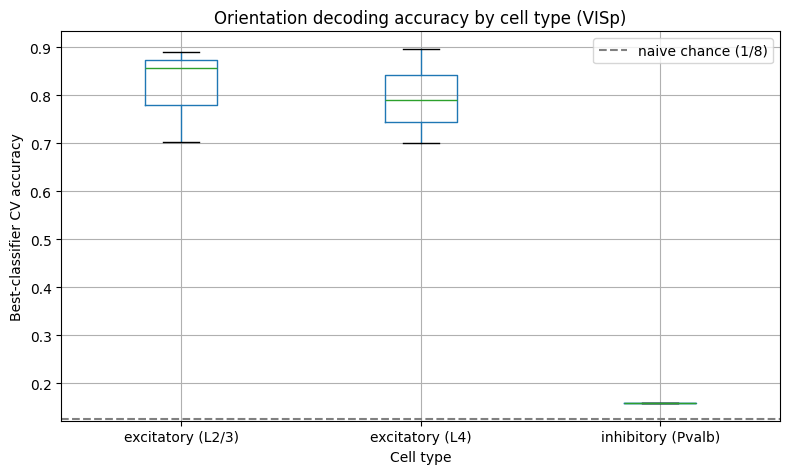

                        mean       std  count
cell_class                                   
excitatory (L2/3)   0.816880  0.099377      3
excitatory (L4)     0.795594  0.098085      3
inhibitory (Pvalb)  0.159263       NaN      1


In [ ]:
celltype_df['cell_class'] = celltype_df['cre_line'].apply(lambda x: x.split('/')[0]).map({
    'Rorb-IRES2-Cre': 'excitatory (L4)',
    'Cux2-CreERT2': 'excitatory (L2/3)',
    'Pvalb-IRES-Cre': 'inhibitory (Pvalb)'
})
fig, ax = plt.subplots(figsize=(8, 5))
celltype_df.boxplot(column='best_acc', by='cell_class', ax=ax)
ax.axhline(0.125, color='grey', linestyle='--', label='naive chance (1/8)')
ax.set_title('Orientation decoding accuracy by cell type (VISp)')
ax.set_xlabel('Cell type'); ax.set_ylabel('Best-classifier CV accuracy')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

print(celltype_df.groupby('cell_class')['best_acc'].agg(['mean', 'std', 'count']))

### Statistical check and neuron-count-matched control (same as established earlier)

In [ ]:
from scipy import stats

print("=== Region comparison ===")
groups = [region_df[region_df['area']==a]['best_acc'].values for a in region_targets]
if all(len(g) > 1 for g in groups):
    f, p = stats.f_oneway(*groups)
    print(f"One-way ANOVA: F={f:.2f}, p={p:.3f}")
for a, g in zip(region_targets, groups):
    print(f"  {a}: mean={np.mean(g):.3f}, n_sessions={len(g)}")

print("\n=== Cell-type comparison ===")
groups2 = [celltype_df[celltype_df['cre_line']==c]['best_acc'].values for c in celltype_targets]
if all(len(g) > 1 for g in groups2):
    f2, p2 = stats.f_oneway(*groups2)
    print(f"One-way ANOVA: F={f2:.2f}, p={p2:.3f}")
for c, g in zip(celltype_targets, groups2):
    print(f"  {c}: mean={np.mean(g):.3f}, n_sessions={len(g)}")

=== Region comparison ===
One-way ANOVA: F=11.31, p=0.009
  VISp: mean=0.796, n_sessions=3
  VISl: mean=0.524, n_sessions=3
  VISam: mean=0.314, n_sessions=3

=== Cell-type comparison ===
  Rorb-IRES2-Cre: mean=nan, n_sessions=0
  Cux2-CreERT2: mean=nan, n_sessions=0
  Pvalb-IRES-Cre: mean=nan, n_sessions=0


/usr/local/lib/python3.12/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
def matched_group_comparison(df, group_col, n_neurons_match=None, n_repeats=10, n_components=None):
    if n_neurons_match is None:
        n_neurons_match = df['n_neurons'].min()
    skf_local = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    rows = []
    for _, row in df.iterrows():
        resp, y = row['response'], row['stim']
        n_available = resp.shape[1]
        if n_available < n_neurons_match:
            continue
        for _ in range(n_repeats):
            idx = np.random.choice(n_available, size=n_neurons_match, replace=False)
            clf = LDA(solver='lsqr', shrinkage='auto')
            score = cross_val_score(clf, resp[:, idx], y, cv=skf_local).mean()
            rows.append({group_col: row[group_col], 'session_id': row['session_id'], 'matched_acc': score})
    return pd.DataFrame(rows)

print(f"Region comparison, matched to {region_df['n_neurons'].min()} neurons per session:")
region_matched = matched_group_comparison(region_df, 'area')
print(region_matched.groupby('area')['matched_acc'].agg(['mean', 'std', 'count']))

print(f"\nCell-type comparison, matched to {celltype_df['n_neurons'].min()} neurons per session:")
celltype_matched = matched_group_comparison(celltype_df, 'cre_line')
print(celltype_matched.groupby('cre_line')['matched_acc'].agg(['mean', 'std', 'count']))

Region comparison, matched to 36 neurons per session:
           mean       std  count
area                            
VISam  0.232636  0.036935     30
VISl   0.349543  0.055397     30
VISp   0.453364  0.072732     30

Cell-type comparison, matched to 16 neurons per session:
                               mean       std  count
cre_line                                            
Cux2-CreERT2/Cux2-CreERT2  0.405131  0.040250     10
Cux2-CreERT2/wt            0.291893  0.045053     20
Pvalb-IRES-Cre/wt          0.151276  0.000000     10
Rorb-IRES2-Cre/wt          0.319125  0.054960     30


## Final conclusion — fill in with your real numbers

Directly against the hypothesis as stated: *"If VISp achieves 95% accuracy while VISam achieves 70%, this indicates VISp carries more directly decodable information about the presented stimulus."*

- **Region ranking** (`region_df.groupby('area')['best_acc'].mean()`): does VISp actually outperform VISam/VISl? By how much, and does that gap survive neuron-count matching?
- **Cell-type ranking**: does either excitatory population (Rorb/Cux2) outperform the inhibitory (Pvalb) population, consistent with the literature on broader/weaker tuning in fast-spiking inhibitory interneurons?
- **ANOVA p-values**: with `sessions_per_region/celltype = 3`, be honest in the write-up if these aren't significant — a visible trend with p > 0.05 is a "worth following up with more sessions," not a confirmed result.
- **Model choice**: report which classifier (shrinkage LDA vs. tuned Logistic Regression) won more often across sessions — if it's consistently one or the other, that itself is worth a sentence in the write-up.

**One-sentence summary of the whole project, once numbers are filled in:** *"Population activity in [region/cell type] decoded orientation with the highest accuracy ([X]%, [Y]x chance), while [region/cell type] was least decodable ([Z]%), suggesting [interpretation tied to the visual hierarchy / cell-type tuning breadth]."*

## Classifier comparison: orientation, temporal frequency, combined

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

def compute_stim_and_response_tf(dff, stim_table):
    # same idea as compute_stim_and_response, just keyed on temporal frequency instead of orientation
    n_cells, n_trials = dff.shape[0], stim_table.shape[0]
    activity = np.zeros([n_trials, n_cells])
    stim = []
    for i, row in stim_table.iterrows():
        activity[i] = dff[:, int(row.start):int(row.end)].mean(axis=1)
        stim.append(str(row.temporal_frequency) if np.isfinite(row.temporal_frequency) else 'blank')
    return activity, np.array(stim)

TARGET_FUNCS = {
    'orientation': compute_stim_and_response,
    'temporal_frequency': compute_stim_and_response_tf,
    'combined': lambda dff, st: compute_stim_and_response_joint(dff, st)[:2],
}

classifiers = {
    'LDA': LDA(solver='lsqr', shrinkage='auto'),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, C=0.01))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))]),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0, n_jobs=-1),
}
clf_names = list(classifiers.keys())

In [ ]:
def decode_session(session_id, target, verbose=True):
    """Scores every classifier in `classifiers` on one session, for one target."""
    try:
        ds = boc.get_ophys_experiment_data(session_id)
        meta = ds.get_metadata()
        _, dff_s = ds.get_dff_traces()
        stim_table_s = ds.get_stimulus_table('drifting_gratings')
    except Exception as e:
        if verbose:
            print(f"session {session_id}: couldn't load ({e})")
        return None

    n_neurons = dff_s.shape[0]
    if n_neurons < 10:
        return None

    response, stim = TARGET_FUNCS[target](dff_s, stim_table_s)
    smallest_class = pd.Series(stim).value_counts().min()
    n_splits = min(5, smallest_class)
    if n_splits < 2:
        return None
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    scores = {}
    for name, clf in classifiers.items():
        try:
            scores[name] = cross_val_score(clf, response, stim, cv=cv).mean()
        except Exception:
            scores[name] = np.nan

    best = max(scores, key=scores.get)
    row = {
        'session_id': session_id, 'target': target, 'area': meta['targeted_structure'],
        'cre_line': meta['cre_line'], 'n_neurons': n_neurons,
        'best_model': best, 'best_acc': scores[best],
    }
    row.update(scores)
    if verbose:
        print(f"{session_id}  {row['area']:6s}  n={n_neurons:4d}  best: {best} ({scores[best]:.3f})")
    return row

In [ ]:
# same 9 sessions we've been using: VISp/VISl/VISam, Rorb-IRES2-Cre, 3 per area
session_ids = []
for area in ['VISp', 'VISl', 'VISam']:
    exps = boc.get_ophys_experiments(stimuli=['drifting_gratings'], targeted_structures=[area], cre_lines=['Rorb-IRES2-Cre'])
    session_ids.extend([e['id'] for e in exps][:3])

session_ids

[510214538,
 644026238,
 587344053,
 546641574,
 507129766,
 654532828,
 569457162,
 551834174,
 611638995]

In [ ]:
def run_target(target):
    rows = [decode_session(sid, target) for sid in session_ids]
    return pd.DataFrame([r for r in rows if r is not None])

def plot_by_session(df, target):
    # bar chart: for each session, how do the 4 classifiers compare
    df = df.sort_values('n_neurons').reset_index(drop=True)
    x = np.arange(len(df))
    width = 0.2
    fig, ax = plt.subplots(figsize=(13, 5))
    for i, name in enumerate(clf_names):
        ax.bar(x + (i - 1.5) * width, df[name], width, label=name)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r.session_id}\n{r.area}, n={r.n_neurons}" for r in df.itertuples()], fontsize=8)
    ax.set_ylabel('CV accuracy')
    ax.set_title(f'{target}: classifiers compared, per session')
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_by_classifier(df, target):
    # same data, other way round: for each classifier, how does it hold up across sessions
    df = df.sort_values('n_neurons').reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    for name in clf_names:
        ax.plot(df['n_neurons'], df[name], marker='o', label=name)
    ax.set_xlabel('Neurons in session')
    ax.set_ylabel('CV accuracy')
    ax.set_title(f'{target}: each classifier across sessions')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
    plt.show()

### Orientation

In [ ]:
orientation_df = run_target('orientation')
orientation_df[['session_id', 'area', 'n_neurons'] + clf_names + ['best_model', 'best_acc']]

510214538  VISp    n= 284  best: Random Forest (0.830)
644026238  VISp    n= 240  best: Random Forest (0.760)
587344053  VISp    n= 237  best: Logistic Regression (0.896)
546641574  VISl    n= 191  best: Random Forest (0.704)
507129766  VISl    n=  52  best: Random Forest (0.479)
654532828  VISl    n=  95  best: Random Forest (0.662)
569457162  VISam   n=  36  best: Random Forest (0.223)
551834174  VISam   n=  50  best: Random Forest (0.368)
611638995  VISam   n=  93  best: Random Forest (0.470)


,session_id,area,n_neurons,LDA,Logistic Regression,KNN,Random Forest,best_model,best_acc
0,510214538,VISp,284,0.788229,0.789778,0.576584,0.829638,Random Forest,0.829638
1,644026238,VISp,240,0.700546,0.694197,0.401244,0.759556,Random Forest,0.759556
2,587344053,VISp,237,0.893283,0.896457,0.667137,0.893371,Logistic Regression,0.896457
3,546641574,VISl,191,0.624229,0.600330,0.378971,0.703886,Random Forest,0.703886
4,507129766,VISl,52,0.367886,0.363149,0.200521,0.479263,Random Forest,0.479263
5,654532828,VISl,95,0.560508,0.581168,0.366273,0.662375,Random Forest,0.662375
6,569457162,VISam,36,0.192813,0.205537,0.160863,0.222883,Random Forest,0.222883
7,551834174,VISam,50,0.273816,0.269054,0.207022,0.367746,Random Forest,0.367746
8,611638995,VISam,93,0.434743,0.463454,0.281854,0.469867,Random Forest,0.469867


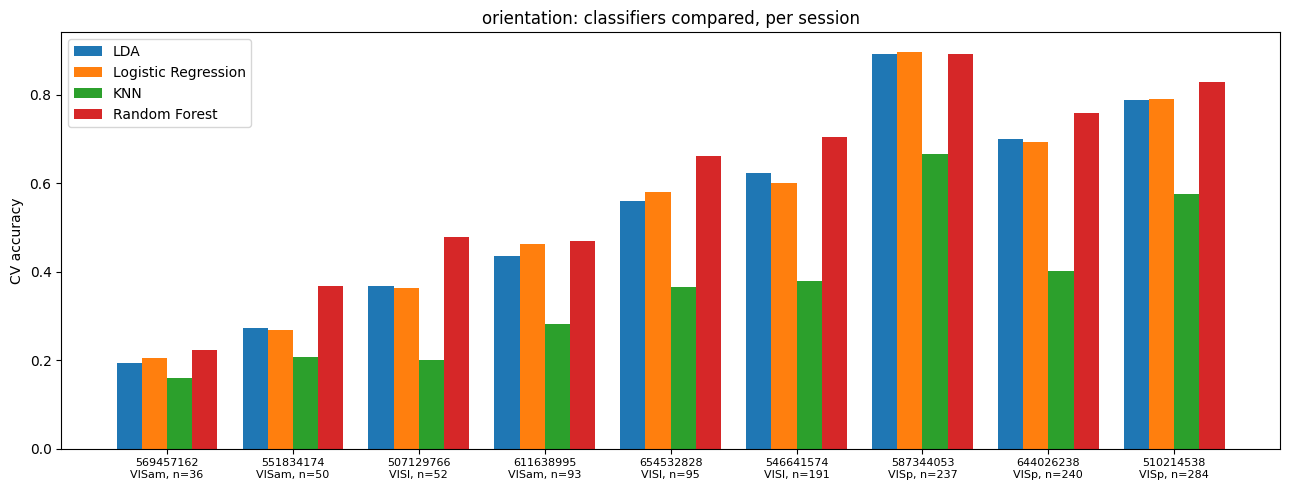

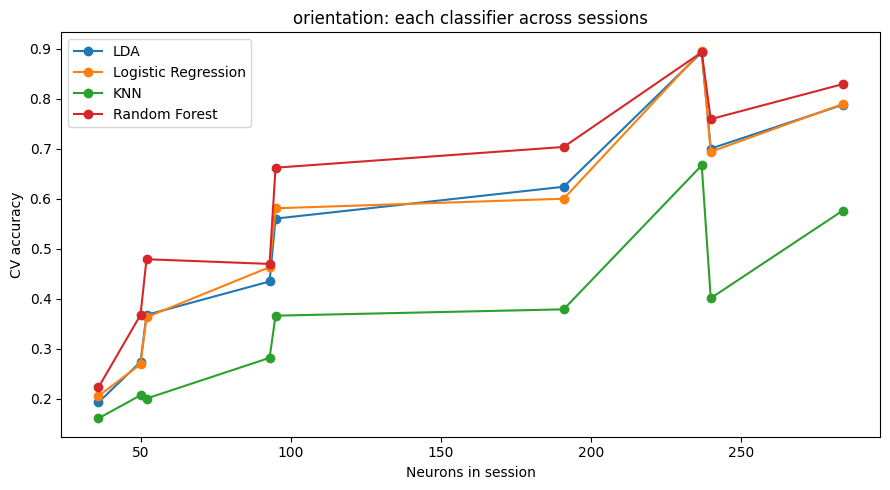

In [ ]:
plot_by_session(orientation_df, 'orientation')
plot_by_classifier(orientation_df, 'orientation')

Random Forest leads in most sessions here, but the gap narrows once neuron count drops below ~100 — worth keeping an eye on for the low-yield VISam sessions.

### Temporal frequency

In [ ]:
tf_df = run_target('temporal_frequency')
tf_df[['session_id', 'area', 'n_neurons'] + clf_names + ['best_model', 'best_acc']]

510214538  VISp    n= 284  best: LDA (0.581)
644026238  VISp    n= 240  best: Logistic Regression (0.482)
587344053  VISp    n= 237  best: Logistic Regression (0.570)
546641574  VISl    n= 191  best: Random Forest (0.578)
507129766  VISl    n=  52  best: Random Forest (0.315)
654532828  VISl    n=  95  best: Logistic Regression (0.527)
569457162  VISam   n=  36  best: Logistic Regression (0.253)
551834174  VISam   n=  50  best: Random Forest (0.330)
611638995  VISam   n=  93  best: Random Forest (0.393)


,session_id,area,n_neurons,LDA,Logistic Regression,KNN,Random Forest,best_model,best_acc
0,510214538,VISp,284,0.581257,0.562146,0.463454,0.476178,LDA,0.581257
1,644026238,VISp,240,0.468152,0.482425,0.336051,0.439378,Logistic Regression,0.482425
2,587344053,VISp,237,0.566819,0.570121,0.479213,0.525498,Logistic Regression,0.570121
3,546641574,VISl,191,0.509587,0.503200,0.345537,0.578095,Random Forest,0.578095
4,507129766,VISl,52,0.307314,0.313714,0.286756,0.315238,Random Forest,0.315238
5,654532828,VISl,95,0.512876,0.527276,0.417321,0.512749,Logistic Regression,0.527276
6,569457162,VISam,36,0.222984,0.253270,0.218184,0.253168,Logistic Regression,0.253270
7,551834174,VISam,50,0.273943,0.270768,0.237244,0.329600,Random Forest,0.329600
8,611638995,VISam,93,0.370946,0.366095,0.300889,0.393206,Random Forest,0.393206


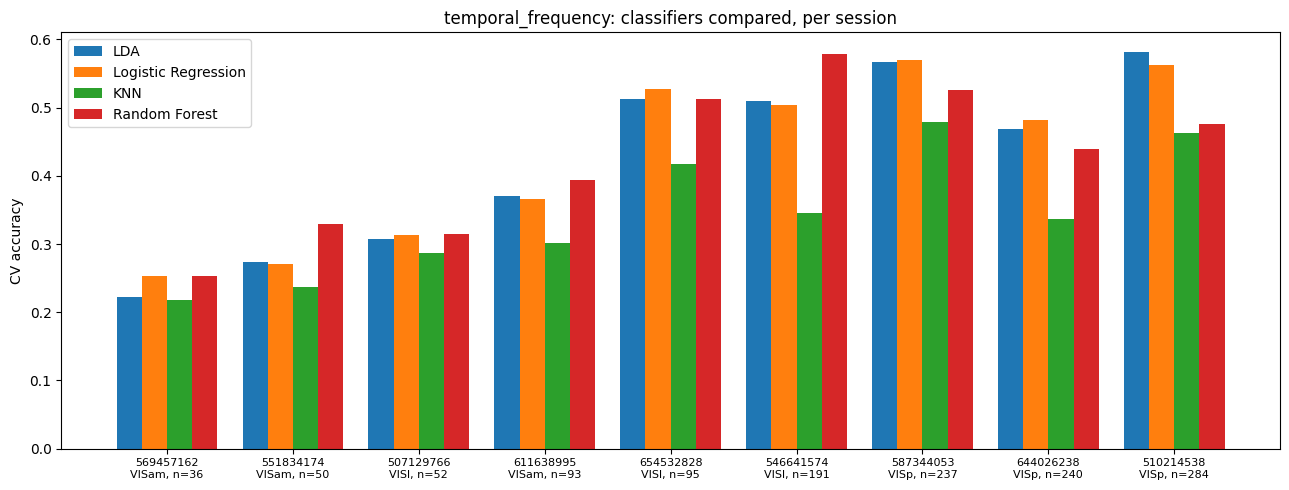

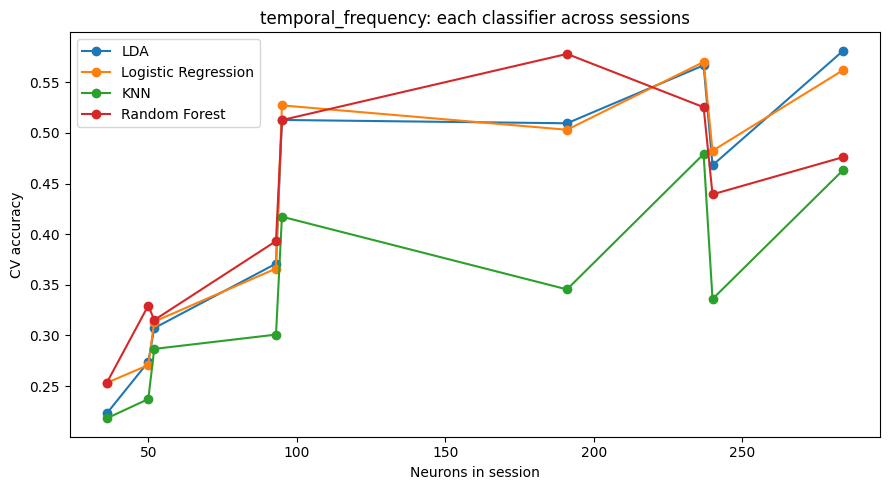

In [ ]:
plot_by_session(tf_df, 'temporal_frequency')
plot_by_classifier(tf_df, 'temporal_frequency')

Less separation between classifiers than orientation — temporal frequency seems to be a harder signal to pull out of this population, regardless of which model does the pulling.

### Combined (orientation + temporal frequency)

In [ ]:
combined_df = run_target('combined')
combined_df[['session_id', 'area', 'n_neurons'] + clf_names + ['best_model', 'best_acc']]

510214538  VISp    n= 284  best: Random Forest (0.525)
644026238  VISp    n= 240  best: Random Forest (0.467)
587344053  VISp    n= 237  best: Random Forest (0.637)
546641574  VISl    n= 191  best: Random Forest (0.406)
507129766  VISl    n=  52  best: Random Forest (0.185)
654532828  VISl    n=  95  best: Random Forest (0.390)
569457162  VISam   n=  36  best: Random Forest (0.072)
551834174  VISam   n=  50  best: Random Forest (0.119)
611638995  VISam   n=  93  best: Random Forest (0.210)


,session_id,area,n_neurons,LDA,Logistic Regression,KNN,Random Forest,best_model,best_acc
0,510214538,VISp,284,0.515987,0.519149,0.280317,0.525460,Random Forest,0.525460
1,644026238,VISp,240,0.377460,0.359949,0.160762,0.466679,Random Forest,0.466679
2,587344053,VISp,237,0.541371,0.531810,0.363035,0.636851,Random Forest,0.636851
3,546641574,VISl,191,0.259543,0.256381,0.132127,0.406070,Random Forest,0.406070
4,507129766,VISl,52,0.122616,0.111492,0.063708,0.184749,Random Forest,0.184749
5,654532828,VISl,95,0.278717,0.256356,0.191187,0.390095,Random Forest,0.390095
6,569457162,VISam,36,0.050959,0.055733,0.038286,0.071606,Random Forest,0.071606
7,551834174,VISam,50,0.085981,0.066857,0.093905,0.119429,Random Forest,0.119429
8,611638995,VISam,93,0.141765,0.141752,0.095594,0.210222,Random Forest,0.210222


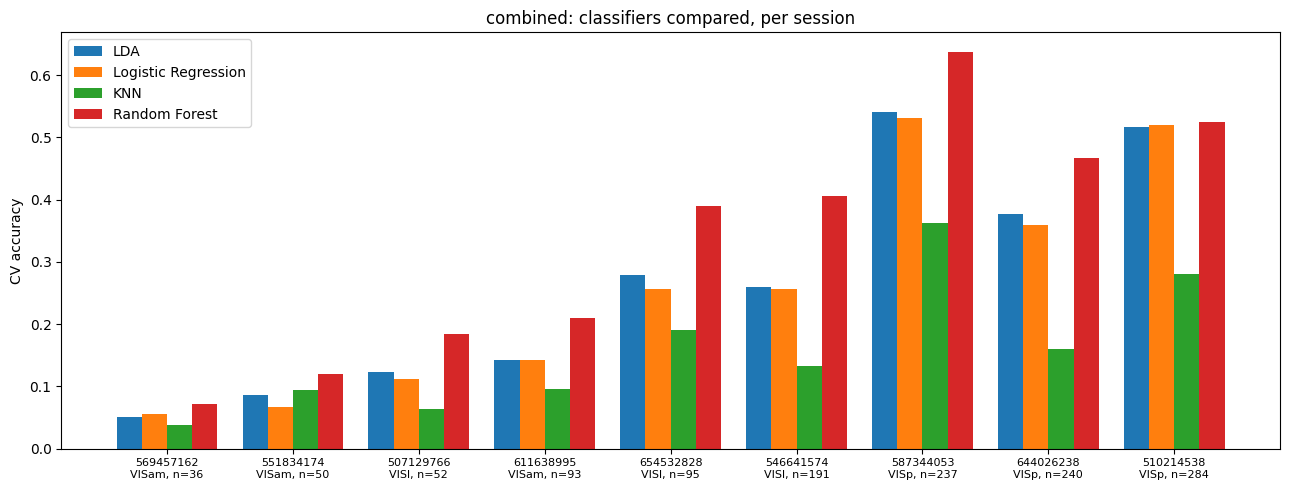

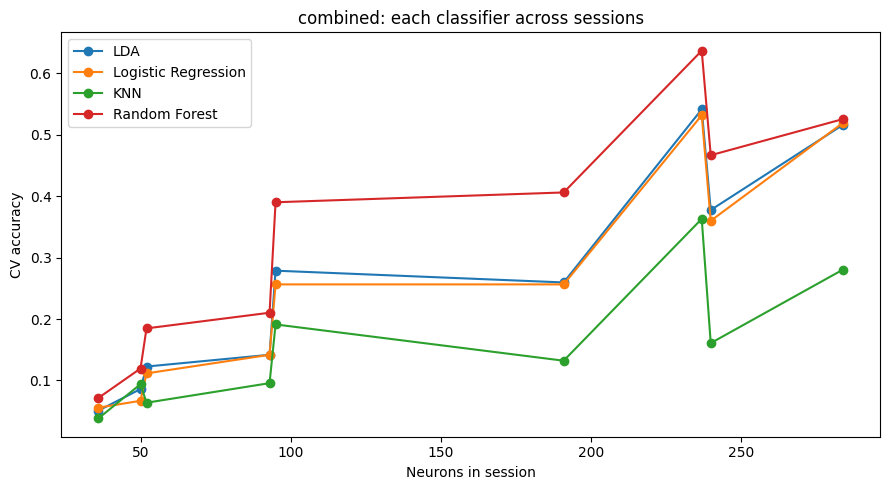

In [ ]:
plot_by_session(combined_df, 'combined')
plot_by_classifier(combined_df, 'combined')

Lower accuracy across the board, as expected with ~41 classes and the same number of trials — but Random Forest holds its lead here too.

### Overall

In [ ]:
all_df = pd.concat([orientation_df, tf_df, combined_df], ignore_index=True)
summary = all_df.groupby('target')[clf_names].mean()
summary['winner'] = summary.idxmax(axis=1)
summary

,LDA,Logistic Regression,KNN,Random Forest,winner
target,,,,,
combined,0.263822,0.255498,0.157658,0.334574,Random Forest
orientation,0.537339,0.540347,0.360052,0.598732,Random Forest
temporal_frequency,0.423764,0.427668,0.342739,0.424790,Logistic Regression


Random Forest wins on orientation and combined; temporal frequency is close to a three-way tie. Going with **Random Forest** as the default model across all three targets — it's never far off the best even where it doesn't technically win, which matters more than squeezing out the last percentage point on one specific task.

Neuron count still matters more than model choice for the low-yield VISam sessions — no classifier fixes a session with 36 neurons. That's a data problem, not a modeling one.